# 06 — Scaled Robustness Experiment

This notebook extends the validated 100-example pilot into a larger
filter-selected experimental corpus.

The objective is to test whether the principal pilot findings remain visible
when the number of source conversations and weak-label-positive examples is
substantially increased.

## Frozen methodology

The scaled experiment reuses the methodological components developed and
validated during the pilot without modifying their rules in response to pilot
results.

The following components remain frozen:

- relevance filter: `relevance_v1`;
- weak-labelling rules: `disempowerment_weak_v5`;
- synthetic noise configuration: `noise_v1`;
- preprocessing configuration: `preprocess_v1`;
- model family: TF-IDF + `LinearSVC`;
- TF-IDF settings: word unigrams and bigrams, lowercase conversion,
  sublinear term frequency and L2 normalization;
- SVM settings: `C=1.0` and balanced class weighting.

Changes to these components would require explicit versioning rather than
silent modification.

## Scaled corpus construction

The scaled corpus is created by streaming LMSYS-Chat-1M using the same pinned
dataset revision and frozen relevance filter used during pilot development.

The initial target is:

- approximately 1,000 unique filter-positive source conversations;
- at most one selected human-assistant pair per source conversation.

The scan will stop when either:

1. 1,000 unique filter-positive sources have been collected; or
2. the configured scan ceiling has been reached.

An initial scan ceiling of approximately 700,000 source records is used. This
is based on the candidate yield observed during pilot development and provides
headroom for reaching the 1,000-source target without loading the complete
dataset into memory.

Selection remains deterministic and reproducible.

## Relationship to manual validation

The original 100-example pilot was manually reviewed for topical relevance.

The larger corpus is not treated as 1,000 manually validated examples.
Instead, it is explicitly described as a **frozen-filter-selected scaled
corpus**.

The scaled stage therefore evaluates whether the already-developed filtering
and weak-labelling pipeline can support a larger robustness experiment without
silently representing automated relevance decisions as human validation.

Targeted manual auditing will be used to inspect:

- a deterministic sample of filter-selected examples;
- weak-label-positive examples;
- any unexpected label or category distributions.

## Scaling decision rule

Weak labels will first be applied to the larger filter-selected corpus before
noise generation or model training.

The resulting class distribution will determine whether the corpus is large
enough for the scaled modelling experiment.

The preferred minimum is approximately 30 weak-label-positive source
conversations.

If substantially fewer than 30 positives are obtained, the scan will be
expanded while keeping the frozen filter and weak-labelling rules unchanged.

The label rules will not be loosened simply to increase the positive count.

## Interpretation

The scaled experiment is intended to test the stability of the pilot findings,
particularly:

- sensitivity to different textual noise types;
- whether preprocessing provides measurable robustness recovery;
- whether aggressive preprocessing continues to remove task-relevant
  linguistic information;
- whether classifier discrimination becomes more stable with a larger
  positive class.

Pilot results are not used to tune the scaled experimental conditions.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/workspaces/irp-disempowerment-nlp")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ------------------------------------------------------------
# Frozen scaled-experiment configuration
# ------------------------------------------------------------

RANDOM_SEED = 42

DATASET_NAME = "lmsys/lmsys-chat-1m"

DATASET_REVISION = (
    "200748d9d3cddcc9d782887541057aca0b18c5da"
)

TARGET_UNIQUE_SOURCES = 1000

INITIAL_SCAN_CEILING = 700_000


print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_NAME)
print("Dataset revision:", DATASET_REVISION)
print("Target unique sources:", TARGET_UNIQUE_SOURCES)
print("Initial scan ceiling:", INITIAL_SCAN_CEILING)
print("Random seed:", RANDOM_SEED)

Project root: /workspaces/irp-disempowerment-nlp
Dataset: lmsys/lmsys-chat-1m
Dataset revision: 200748d9d3cddcc9d782887541057aca0b18c5da
Target unique sources: 1000
Initial scan ceiling: 700000
Random seed: 42


In [2]:
import src.filtering as filtering


public_filtering_names = sorted(
    name
    for name in dir(filtering)
    if not name.startswith("_")
)


print("Public names in src.filtering:")
for name in public_filtering_names:
    print("-", name)


print("\nVersion-related values:")
for name in public_filtering_names:
    if "VERSION" in name.upper():
        try:
            print(
                f"{name}:",
                getattr(filtering, name),
            )
        except Exception:
            pass

Public names in src.filtering:
- ADVICE_PATTERNS
- Any
- Iterable
- MAX_ASSISTANT_CHARS
- MAX_USER_CHARS
- MINOR_CONTEXT_PATTERNS
- MIN_ASSISTANT_CHARS
- MIN_USER_CHARS
- PERSONAL_DECISION_DOMAINS
- PERSONAL_HELP_PATTERNS
- RANDOM_SEED
- RELEVANCE_PATTERNS
- SEXUAL_CONTEXT_PATTERNS
- TASK_EXCLUSION_PATTERNS
- annotations
- build_relevant_candidate_pool
- debug_relevance_matches
- deterministic_sample
- extract_user_assistant_pairs
- is_english
- is_sensitive_exclusion
- is_task_like_prompt
- match_relevance_categories
- pair_is_eligible
- random
- re

Version-related values:


In [3]:
import inspect

functions_to_inspect = [
    filtering.build_relevant_candidate_pool,
    filtering.extract_user_assistant_pairs,
    filtering.pair_is_eligible,
    filtering.deterministic_sample,
]

for func in functions_to_inspect:
    print("=" * 80)
    print(func.__name__)
    print("Signature:")
    print(inspect.signature(func))
    print()

    doc = inspect.getdoc(func)

    if doc:
        print("Docstring:")
        print(doc)
    else:
        print("Docstring: None")

    print()

build_relevant_candidate_pool
Signature:
(dataset: 'Iterable[dict[str, Any]]', max_conversations: 'int') -> 'tuple[list[dict[str, Any]], dict[str, int]]'

Docstring:
Scan a fixed number of streamed LMSYS conversations.

Returns
-------
candidates:
    User-assistant pairs passing both eligibility and relevance checks.

diagnostics:
    Processing counts for this development scan.

These diagnostic counts describe this particular scan only and should
not be interpreted as LMSYS population-level statistics.

extract_user_assistant_pairs
Signature:
(example: 'dict[str, Any]', source_index: 'int') -> 'list[dict[str, Any]]'

Docstring:
Extract adjacent user -> assistant message pairs from one conversation.

We deliberately do not retain LMSYS conversation_id.

source_index provides a non-identifying grouping variable within the
deterministic scan so multiple exchanges from the same source
conversation can still be recognised.

pair_is_eligible
Signature:
(pair: 'dict[str, Any]') -> 'bool'



In [4]:
from datasets import load_dataset


# ------------------------------------------------------------
# Load pinned LMSYS-Chat-1M stream
# ------------------------------------------------------------

dataset_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
    revision=DATASET_REVISION,
)


print("Dataset stream loaded.")
print("Dataset type:", type(dataset_stream))
print("Streaming enabled:", True)

/workspaces/irp-disempowerment-nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset stream loaded.
Dataset type: <class 'datasets.iterable_dataset.IterableDataset'>
Streaming enabled: True


In [5]:
import time


# ------------------------------------------------------------
# Scaled frozen-filter scan
# ------------------------------------------------------------

scan_start = time.perf_counter()

scaled_candidates, scaled_diagnostics = (
    filtering.build_relevant_candidate_pool(
        dataset_stream,
        max_conversations=INITIAL_SCAN_CEILING,
    )
)

scan_elapsed_seconds = (
    time.perf_counter()
    - scan_start
)


scaled_candidate_df = pd.DataFrame(
    scaled_candidates
)

print("Scaled filtering scan complete.")
print(
    "Configured scan ceiling:",
    INITIAL_SCAN_CEILING,
)
print(
    "Raw candidate pairs:",
    len(scaled_candidate_df),
)

if "source_index" in scaled_candidate_df.columns:
    print(
        "Unique candidate sources:",
        scaled_candidate_df["source_index"].nunique(),
    )

print(
    "Elapsed minutes:",
    round(
        scan_elapsed_seconds / 60,
        2,
    ),
)

print("\nScan diagnostics:")
for key, value in scaled_diagnostics.items():
    print(f"{key}: {value}")

KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------------------
# Construct deterministic one-pair-per-source scaled corpus
# ------------------------------------------------------------

assert len(scaled_candidate_df) == 1233
assert scaled_candidate_df["source_index"].nunique() == 1121

assert (
    scaled_candidate_df["source_index"]
    .notna()
    .all()
)

assert (
    scaled_candidate_df["user_text"]
    .notna()
    .all()
)

assert (
    scaled_candidate_df["assistant_text"]
    .notna()
    .all()
)


# First impose a deterministic order, then retain at most one
# relevant human-assistant pair per source conversation.
unique_source_pool_df = (
    scaled_candidate_df
    .sort_values(
        [
            "source_index",
            "pair_index",
        ],
        kind="mergesort",
    )
    .drop_duplicates(
        subset=["source_index"],
        keep="first",
    )
    .reset_index(drop=True)
)


assert (
    unique_source_pool_df["source_index"].nunique()
    == len(unique_source_pool_df)
)

assert len(unique_source_pool_df) == 1121

assert (
    len(unique_source_pool_df)
    >= TARGET_UNIQUE_SOURCES
)


# Deterministically select exactly 1,000 unique sources.
scaled_1000_df = (
    unique_source_pool_df
    .sample(
        n=TARGET_UNIQUE_SOURCES,
        random_state=RANDOM_SEED,
        replace=False,
    )
    .sort_values(
        [
            "source_index",
            "pair_index",
        ]
    )
    .reset_index(drop=True)
)


assert len(scaled_1000_df) == 1000
assert scaled_1000_df["source_index"].nunique() == 1000


print("Unique-source candidate pool:", len(unique_source_pool_df))
print("Scaled corpus rows:", len(scaled_1000_df))
print(
    "Scaled corpus unique sources:",
    scaled_1000_df["source_index"].nunique(),
)

print("Deterministic 1,000-source corpus constructed.")

In [ ]:
# ------------------------------------------------------------
# Save scaled filtering outputs locally
# ------------------------------------------------------------

SCALED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "samples"
)

SCALED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


raw_candidates_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_scan_candidates_1233.csv"
)

unique_pool_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_unique_source_pool_1121.csv"
)

scaled_1000_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_filter_selected_1000.csv"
)


scaled_candidate_df.to_csv(
    raw_candidates_path,
    index=False,
)

unique_source_pool_df.to_csv(
    unique_pool_path,
    index=False,
)

scaled_1000_df.to_csv(
    scaled_1000_path,
    index=False,
)


print("Saved scaled filtering outputs:")

for path in [
    raw_candidates_path,
    unique_pool_path,
    scaled_1000_path,
]:
    print(
        f"- {path.name}:",
        path.exists(),
    )

In [ ]:
# ------------------------------------------------------------
# Apply frozen weak-labelling rules to scaled corpus
# ------------------------------------------------------------

from src.labelling import (
    WEAK_LABEL_VERSION,
    weak_label_disempowerment,
)


assert (
    WEAK_LABEL_VERSION
    == "disempowerment_weak_v5"
)

print(
    "Weak-label version:",
    WEAK_LABEL_VERSION,
)


scaled_weak_records = scaled_1000_df.apply(
    lambda row: weak_label_disempowerment(
        user_text=row["user_text"],
        assistant_text=row["assistant_text"],
    ),
    axis=1,
)


scaled_weak_df = pd.DataFrame(
    scaled_weak_records.tolist(),
    index=scaled_1000_df.index,
)


scaled_labelled_df = pd.concat(
    [
        scaled_1000_df.copy(),
        scaled_weak_df,
    ],
    axis=1,
)


scaled_labelled_df[
    "weak_label_version"
] = WEAK_LABEL_VERSION


print(
    "Labelled rows:",
    len(scaled_labelled_df),
)

print(
    "Unique sources:",
    scaled_labelled_df[
        "source_index"
    ].nunique(),
)

In [ ]:
# ------------------------------------------------------------
# Inspect scaled weak-label distribution
# ------------------------------------------------------------

scaled_label_counts = {
    "sycophantic_validation": int(
        scaled_labelled_df[
            "sycophantic_validation"
        ].sum()
    ),
    "overconfident_judgement": int(
        scaled_labelled_df[
            "overconfident_judgement"
        ].sum()
    ),
    "directive_advice": int(
        scaled_labelled_df[
            "directive_advice"
        ].sum()
    ),
    "weak_label_any": int(
        scaled_labelled_df[
            "weak_label_any"
        ].sum()
    ),
}


print("Scaled weak-label counts:")

for label, count in scaled_label_counts.items():
    print(
        f"{label}: {count}"
    )


positive_count = scaled_label_counts[
    "weak_label_any"
]

negative_count = (
    len(scaled_labelled_df)
    - positive_count
)

positive_pct = (
    positive_count
    / len(scaled_labelled_df)
    * 100
)


print()
print("Negative sources:", negative_count)
print("Positive sources:", positive_count)
print(
    "Positive percentage:",
    round(
        positive_pct,
        2,
    ),
)


print("\nWeak-label combinations:")

print(
    scaled_labelled_df[
        "weak_labels"
    ]
    .fillna("none")
    .replace("", "none")
    .value_counts()
)

In [ ]:
# ------------------------------------------------------------
# Save frozen weak-labelled scaled corpus
# ------------------------------------------------------------

scaled_labelled_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_weak_v5_labelled_1000.csv"
)

scaled_labelled_df.to_csv(
    scaled_labelled_path,
    index=False,
)

print("Saved labelled scaled corpus:")
print(scaled_labelled_path)
print(
    "File exists:",
    scaled_labelled_path.exists(),
)

In [ ]:
# ------------------------------------------------------------
# Independently reload and verify scaled labelled corpus
# ------------------------------------------------------------

saved_scaled_labelled_df = pd.read_csv(
    scaled_labelled_path
)

assert len(saved_scaled_labelled_df) == 1000

assert (
    saved_scaled_labelled_df["source_index"].nunique()
    == 1000
)

assert (
    saved_scaled_labelled_df["weak_label_version"]
    .eq("disempowerment_weak_v5")
    .all()
)

assert int(
    saved_scaled_labelled_df[
        "directive_advice"
    ].sum()
) == 30

assert int(
    saved_scaled_labelled_df[
        "overconfident_judgement"
    ].sum()
) == 4

assert int(
    saved_scaled_labelled_df[
        "sycophantic_validation"
    ].sum()
) == 0

assert int(
    saved_scaled_labelled_df[
        "weak_label_any"
    ].sum()
) == 34


print("Saved scaled labelled corpus verification passed.")
print("Rows:", len(saved_scaled_labelled_df))
print(
    "Positive sources:",
    int(
        saved_scaled_labelled_df[
            "weak_label_any"
        ].sum()
    ),
)

In [ ]:
# ------------------------------------------------------------
# Construct scaled weak-label positive audit table
# ------------------------------------------------------------

scaled_positive_audit_df = (
    saved_scaled_labelled_df[
        saved_scaled_labelled_df[
            "weak_label_any"
        ].eq(True)
    ][
        [
            "source_index",
            "pair_index",
            "user_text",
            "assistant_text",
            "weak_labels",
            "sycophantic_evidence",
            "overconfident_evidence",
            "directive_evidence",
        ]
    ]
    .sort_values(
        [
            "weak_labels",
            "source_index",
            "pair_index",
        ]
    )
    .reset_index(drop=True)
)


# Stable audit number for manual review.
scaled_positive_audit_df[
    "audit_number"
] = (
    np.arange(
        1,
        len(scaled_positive_audit_df) + 1,
    )
)


# Manual audit fields.
# These do not alter the frozen weak labels.
scaled_positive_audit_df[
    "manual_audit_valid"
] = pd.NA

scaled_positive_audit_df[
    "manual_audit_note"
] = ""


# Put audit number first.
audit_columns = [
    "audit_number",
    "source_index",
    "pair_index",
    "weak_labels",
    "sycophantic_evidence",
    "overconfident_evidence",
    "directive_evidence",
    "user_text",
    "assistant_text",
    "manual_audit_valid",
    "manual_audit_note",
]

scaled_positive_audit_df = (
    scaled_positive_audit_df[
        audit_columns
    ]
)


assert len(scaled_positive_audit_df) == 34

assert (
    scaled_positive_audit_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)


print(
    "Positive examples queued for audit:",
    len(scaled_positive_audit_df),
)

print("\nLabel distribution:")

print(
    scaled_positive_audit_df[
        "weak_labels"
    ]
    .value_counts()
)

In [ ]:
# ------------------------------------------------------------
# Compact audit index — no conversation text displayed
# ------------------------------------------------------------

positive_audit_index = (
    scaled_positive_audit_df[
        [
            "audit_number",
            "source_index",
            "pair_index",
            "weak_labels",
            "sycophantic_evidence",
            "overconfident_evidence",
            "directive_evidence",
        ]
    ]
)

positive_audit_index

In [ ]:
# ------------------------------------------------------------
# Manual positive audit — display one example
# ------------------------------------------------------------

AUDIT_NUMBER = 34
audit_row = (
    scaled_positive_audit_df[
        scaled_positive_audit_df["audit_number"]
        == AUDIT_NUMBER
    ]
    .iloc[0]
)


print(
    f"AUDIT {AUDIT_NUMBER} OF "
    f"{len(scaled_positive_audit_df)}"
)

print("=" * 80)

print("Source index:", audit_row["source_index"])
print("Pair index:", audit_row["pair_index"])
print("Weak label:", audit_row["weak_labels"])

print(
    "Sycophantic evidence:",
    audit_row["sycophantic_evidence"],
)

print(
    "Overconfident evidence:",
    audit_row["overconfident_evidence"],
)

print(
    "Directive evidence:",
    audit_row["directive_evidence"],
)

print("\nUSER:")
print(audit_row["user_text"])

print("\nASSISTANT:")
print(audit_row["assistant_text"])

In [ ]:
scaled_positive_audit_df.loc[
    scaled_positive_audit_df["audit_number"] == 34,
    ["manual_audit_valid", "manual_audit_note"]
] = [
    0,
    "False positive: relationship language reflects the user's reported experience and feelings rather than an unsupported confident judgement by the assistant about the parents' hidden motives or feelings."
]

In [ ]:
# ------------------------------------------------------------
# Verify completed scaled positive audit
# ------------------------------------------------------------

audit_valid_numeric = pd.to_numeric(
    scaled_positive_audit_df["manual_audit_valid"],
    errors="coerce",
)


reviewed_count = int(
    audit_valid_numeric.notna().sum()
)

valid_count = int(
    audit_valid_numeric.sum()
)

false_positive_count = (
    reviewed_count - valid_count
)


print("Audit completion:")
print("Reviewed:", reviewed_count, "/ 34")
print("Valid:", valid_count)
print("False positives:", false_positive_count)


assert reviewed_count == 34
assert valid_count == 12
assert false_positive_count == 22


# ------------------------------------------------------------
# Breakdown by frozen weak-label category
# ------------------------------------------------------------

audit_summary_input = (
    scaled_positive_audit_df.copy()
)

audit_summary_input[
    "manual_audit_valid_numeric"
] = audit_valid_numeric


audit_category_summary = (
    audit_summary_input
    .groupby("weak_labels")
    .agg(
        detected=(
            "audit_number",
            "size",
        ),
        valid=(
            "manual_audit_valid_numeric",
            "sum",
        ),
    )
)


audit_category_summary["valid"] = (
    audit_category_summary["valid"]
    .astype(int)
)

audit_category_summary["false_positive"] = (
    audit_category_summary["detected"]
    - audit_category_summary["valid"]
)

audit_category_summary["audit_precision_pct"] = (
    audit_category_summary["valid"]
    / audit_category_summary["detected"]
    * 100
).round(1)


print("\nAudit results by weak-label category:")
audit_category_summary

In [ ]:
# ------------------------------------------------------------
# Save completed scaled positive audit
# ------------------------------------------------------------

scaled_positive_audit_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_weak_v5_positive_audit_34.csv"
)

scaled_positive_audit_df.to_csv(
    scaled_positive_audit_path,
    index=False,
)

print("Saved completed positive audit:")
print(scaled_positive_audit_path)
print(
    "File exists:",
    scaled_positive_audit_path.exists(),
)

In [ ]:
# ------------------------------------------------------------
# Reload and verify completed audit
# ------------------------------------------------------------

saved_positive_audit_df = pd.read_csv(
    scaled_positive_audit_path
)

assert len(saved_positive_audit_df) == 34

assert (
    saved_positive_audit_df[
        "manual_audit_valid"
    ].notna().all()
)

assert int(
    saved_positive_audit_df[
        "manual_audit_valid"
    ].sum()
) == 12

assert int(
    (
        saved_positive_audit_df[
            "manual_audit_valid"
        ] == 0
    ).sum()
) == 22


print("Saved positive-audit verification passed.")
print("Rows:", len(saved_positive_audit_df))
print(
    "Valid detections:",
    int(
        saved_positive_audit_df[
            "manual_audit_valid"
        ].sum()
    ),
)
print(
    "False positives:",
    int(
        (
            saved_positive_audit_df[
                "manual_audit_valid"
            ] == 0
        ).sum()
    ),
)

## Scaled weak-label audit outcome

The initial scaled corpus contained 1,000 unique filter-selected source
conversations.

Applying the frozen `disempowerment_weak_v5` rules produced:

- 34 weak-label-positive sources;
- 966 weak-label-negative sources;
- 30 `directive_advice` detections;
- 4 `overconfident_judgement` detections;
- 0 `sycophantic_validation` detections.

All 34 weak-label-positive examples were manually audited without modifying
the frozen weak-labelling rules.

The audit found:

- 12 valid detections;
- 22 false positives;
- overall audited precision: approximately 35.3%.

By category:

- `directive_advice`: 11/30 valid (36.7%);
- `overconfident_judgement`: 1/4 valid (25.0%).

The main false-positive sources included:

- procedural technical or business instructions;
- fictional or roleplay dialogue;
- appropriate medical, safety, consent, or boundary guidance;
- autonomy-preserving reflective advice;
- task/evaluation content containing surface-form lexical matches.

These findings are retained as a diagnostic of the frozen weak-labelling
pipeline rather than used to silently alter `disempowerment_weak_v5`.

Although the raw weak-label count exceeded the initial target of 30 positives,
the manual audit showed that only 12 detections were convincing under the
study's operational definitions.

The scaled corpus is therefore expanded before model training.

The filtering and weak-labelling rules remain frozen. The next scan increases
coverage of LMSYS-Chat-1M rather than relaxing the label criteria.

The expanded scan will use a ceiling of 1,000,000 source conversations, which
approaches the full available dataset while preserving the same pinned dataset
revision and deterministic filtering procedure.

In [ ]:
# ------------------------------------------------------------
# Expanded frozen-filter scan: up to 1,000,000 conversations
# ------------------------------------------------------------

FULL_SCAN_CEILING = 1_000_000


# Create a fresh stream so the expanded scan starts deterministically
# from the beginning of the same pinned dataset revision.
full_dataset_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
    revision=DATASET_REVISION,
)


full_scan_start = time.perf_counter()

full_scaled_candidates, full_scaled_diagnostics = (
    filtering.build_relevant_candidate_pool(
        full_dataset_stream,
        max_conversations=FULL_SCAN_CEILING,
    )
)

full_scan_elapsed_seconds = (
    time.perf_counter()
    - full_scan_start
)


full_scaled_candidate_df = pd.DataFrame(
    full_scaled_candidates
)


print("Expanded filtering scan complete.")
print(
    "Configured scan ceiling:",
    FULL_SCAN_CEILING,
)
print(
    "Raw candidate pairs:",
    len(full_scaled_candidate_df),
)
print(
    "Unique candidate sources:",
    full_scaled_candidate_df[
        "source_index"
    ].nunique(),
)
print(
    "Elapsed minutes:",
    round(
        full_scan_elapsed_seconds / 60,
        2,
    ),
)


print("\nScan diagnostics:")

for key, value in full_scaled_diagnostics.items():
    print(f"{key}: {value}")


# ------------------------------------------------------------
# Save immediately so the expensive scan does not need repeating
# ------------------------------------------------------------

full_scan_candidates_path = (
    SCALED_DATA_DIR
    / "lmsys_full_scan_candidates_1m.csv"
)

full_scaled_candidate_df.to_csv(
    full_scan_candidates_path,
    index=False,
)


print("\nSaved expanded scan candidates:")
print(full_scan_candidates_path)
print(
    "File exists:",
    full_scan_candidates_path.exists(),
)

In [ ]:
# ------------------------------------------------------------
# Construct full one-pair-per-source scaled pool
# ------------------------------------------------------------

full_unique_source_pool_df = (
    full_scaled_candidate_df
    .sort_values(
        [
            "source_index",
            "pair_index",
        ],
        kind="mergesort",
    )
    .drop_duplicates(
        subset=["source_index"],
        keep="first",
    )
    .reset_index(drop=True)
)


assert len(full_unique_source_pool_df) == 1633

assert (
    full_unique_source_pool_df[
        "source_index"
    ].nunique()
    == 1633
)


full_unique_pool_path = (
    SCALED_DATA_DIR
    / "lmsys_full_unique_source_pool_1633.csv"
)

full_unique_source_pool_df.to_csv(
    full_unique_pool_path,
    index=False,
)


print(
    "Full unique-source pool:",
    len(full_unique_source_pool_df),
)

print(
    "Unique sources:",
    full_unique_source_pool_df[
        "source_index"
    ].nunique(),
)

print(
    "Saved:",
    full_unique_pool_path.exists(),
)

In [ ]:
# ------------------------------------------------------------
# Apply frozen weak_v5 to all 1,633 unique sources
# ------------------------------------------------------------

assert (
    WEAK_LABEL_VERSION
    == "disempowerment_weak_v5"
)


full_weak_records = (
    full_unique_source_pool_df.apply(
        lambda row:
        weak_label_disempowerment(
            user_text=row["user_text"],
            assistant_text=row["assistant_text"],
        ),
        axis=1,
    )
)


full_weak_df = pd.DataFrame(
    full_weak_records.tolist(),
    index=full_unique_source_pool_df.index,
)


full_labelled_df = pd.concat(
    [
        full_unique_source_pool_df.copy(),
        full_weak_df,
    ],
    axis=1,
)


full_labelled_df[
    "weak_label_version"
] = WEAK_LABEL_VERSION


full_labelled_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_labelled_1633.csv"
)

full_labelled_df.to_csv(
    full_labelled_path,
    index=False,
)


full_positive_count = int(
    full_labelled_df[
        "weak_label_any"
    ].sum()
)


print("Full frozen weak-label counts:")
print(
    "sycophantic_validation:",
    int(
        full_labelled_df[
            "sycophantic_validation"
        ].sum()
    ),
)

print(
    "overconfident_judgement:",
    int(
        full_labelled_df[
            "overconfident_judgement"
        ].sum()
    ),
)

print(
    "directive_advice:",
    int(
        full_labelled_df[
            "directive_advice"
        ].sum()
    ),
)

print(
    "weak_label_any:",
    full_positive_count,
)

print(
    "Positive percentage:",
    round(
        full_positive_count
        / len(full_labelled_df)
        * 100,
        2,
    ),
)

print(
    "Saved labelled pool:",
    full_labelled_path.exists(),
)

In [ ]:
# ------------------------------------------------------------
# Identify newly discovered weak positives
# ------------------------------------------------------------

previously_audited_keys = set(
    zip(
        saved_positive_audit_df[
            "source_index"
        ],
        saved_positive_audit_df[
            "pair_index"
        ],
    )
)


full_positive_df = (
    full_labelled_df[
        full_labelled_df[
            "weak_label_any"
        ].eq(True)
    ]
    .copy()
)


full_positive_df[
    "source_pair_key"
] = list(
    zip(
        full_positive_df[
            "source_index"
        ],
        full_positive_df[
            "pair_index"
        ],
    )
)


new_positive_df = (
    full_positive_df[
        ~full_positive_df[
            "source_pair_key"
        ].isin(
            previously_audited_keys
        )
    ]
    .drop(
        columns=["source_pair_key"]
    )
    .sort_values(
        [
            "weak_labels",
            "source_index",
            "pair_index",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Total weak positives in 1,633-source pool:",
    len(full_positive_df),
)

print(
    "Previously audited positives:",
    len(
        full_positive_df[
            full_positive_df[
                "source_pair_key"
            ].isin(
                previously_audited_keys
            )
        ]
    ),
)

print(
    "New positives requiring audit:",
    len(new_positive_df),
)

print("\nNew-positive label distribution:")

print(
    new_positive_df[
        "weak_labels"
    ].value_counts()
)

In [ ]:
# ------------------------------------------------------------
# Construct audit queue for the 22 newly discovered positives
# ------------------------------------------------------------

expanded_positive_audit_df = (
    new_positive_df[
        [
            "source_index",
            "pair_index",
            "user_text",
            "assistant_text",
            "weak_labels",
            "sycophantic_evidence",
            "overconfident_evidence",
            "directive_evidence",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# Continue numbering from the original 34-example audit.
expanded_positive_audit_df["audit_number"] = (
    np.arange(
        35,
        35 + len(expanded_positive_audit_df),
    )
)


expanded_positive_audit_df[
    "manual_audit_valid"
] = pd.NA

expanded_positive_audit_df[
    "manual_audit_note"
] = ""


audit_columns = [
    "audit_number",
    "source_index",
    "pair_index",
    "weak_labels",
    "sycophantic_evidence",
    "overconfident_evidence",
    "directive_evidence",
    "user_text",
    "assistant_text",
    "manual_audit_valid",
    "manual_audit_note",
]

expanded_positive_audit_df = (
    expanded_positive_audit_df[
        audit_columns
    ]
)


assert len(expanded_positive_audit_df) == 22

assert (
    expanded_positive_audit_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    expanded_positive_audit_df[
        "audit_number"
    ].tolist()
    == list(range(35, 57))
)


print(
    "New positives queued for audit:",
    len(expanded_positive_audit_df),
)

print(
    "Audit numbers:",
    expanded_positive_audit_df[
        "audit_number"
    ].min(),
    "to",
    expanded_positive_audit_df[
        "audit_number"
    ].max(),
)

print("\nLabel distribution:")

print(
    expanded_positive_audit_df[
        "weak_labels"
    ].value_counts()
)

In [ ]:
# ------------------------------------------------------------
# Compact index for newly discovered positives
# ------------------------------------------------------------

expanded_audit_index = (
    expanded_positive_audit_df[
        [
            "audit_number",
            "source_index",
            "pair_index",
            "weak_labels",
            "sycophantic_evidence",
            "overconfident_evidence",
            "directive_evidence",
        ]
    ]
)

expanded_audit_index

In [5]:
# ------------------------------------------------------------
# Expanded manual positive audit — display one example
# ------------------------------------------------------------

AUDIT_NUMBER = 56

audit_row = (
    expanded_positive_audit_df[
        expanded_positive_audit_df["audit_number"]
        == AUDIT_NUMBER
    ]
    .iloc[0]
)


print(
    f"AUDIT {AUDIT_NUMBER} OF 56"
)

print("=" * 80)

print("Source index:", audit_row["source_index"])
print("Pair index:", audit_row["pair_index"])
print("Weak label:", audit_row["weak_labels"])

print(
    "Sycophantic evidence:",
    audit_row["sycophantic_evidence"],
)

print(
    "Overconfident evidence:",
    audit_row["overconfident_evidence"],
)

print(
    "Directive evidence:",
    audit_row["directive_evidence"],
)

print("\nUSER:")
print(audit_row["user_text"])

print("\nASSISTANT:")
print(audit_row["assistant_text"])

AUDIT 56 OF 56
Source index: 820643
Pair index: 0
Weak label: sycophantic_validation
Sycophantic evidence: strong_entitlement_validation
Overconfident evidence: nan
Directive evidence: nan

USER:
the summary of the story : 'One night, I was feeling very horny and started chatting with strangers on Omegle. I was feeling very sleepy and was about to close the tab and suddenly, I was connected with a stranger who called herself NAME_1, 43F. I fell in love with that name and I wanted to know more about this NAME_1 aunty. She said she was living with her children, a son, and a daughter, in an apartment and that she lost her husband many years ago. She said she was feeling very alone after the demise of her husband and that it was been 4 years since she last had sex. I felt sorry for her as I could guess how hard it would be for a married person to stay away from sex for that long time. I mean, there are a lot of young men in our country who would literally form queues to fuck a 43-year-old 

In [6]:
expanded_positive_audit_df.loc[
    expanded_positive_audit_df["audit_number"] == 56,
    ["manual_audit_valid", "manual_audit_note"]
] = [
    0,
    "False positive: 'you have every right to report' is appropriate supportive/safety-oriented validation after reported harassment, not sycophantic endorsement of the user's judgement or decision."
]

In [7]:
# ------------------------------------------------------------
# Combine and save the complete 56-example positive audit
# ------------------------------------------------------------

complete_positive_audit_df = pd.concat(
    [
        saved_positive_audit_df.copy(),
        expanded_positive_audit_df.copy(),
    ],
    ignore_index=True,
)


complete_positive_audit_df = (
    complete_positive_audit_df
    .sort_values("audit_number")
    .reset_index(drop=True)
)


# Convert audit decisions to numeric for reliable summaries.
complete_positive_audit_df[
    "manual_audit_valid"
] = pd.to_numeric(
    complete_positive_audit_df[
        "manual_audit_valid"
    ],
    errors="coerce",
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(complete_positive_audit_df) == 56

assert (
    complete_positive_audit_df[
        "audit_number"
    ].tolist()
    == list(range(1, 57))
)

assert (
    complete_positive_audit_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    complete_positive_audit_df[
        "manual_audit_valid"
    ]
    .notna()
    .all()
)


total_valid = int(
    complete_positive_audit_df[
        "manual_audit_valid"
    ].sum()
)

total_false_positive = (
    len(complete_positive_audit_df)
    - total_valid
)


assert total_valid == 16
assert total_false_positive == 40


# ------------------------------------------------------------
# Final audit summary by weak-label category
# ------------------------------------------------------------

final_audit_summary = (
    complete_positive_audit_df
    .groupby("weak_labels")
    .agg(
        detected=("audit_number", "size"),
        valid=("manual_audit_valid", "sum"),
    )
)

final_audit_summary["valid"] = (
    final_audit_summary["valid"]
    .astype(int)
)

final_audit_summary["false_positive"] = (
    final_audit_summary["detected"]
    - final_audit_summary["valid"]
)

final_audit_summary["audit_precision_pct"] = (
    final_audit_summary["valid"]
    / final_audit_summary["detected"]
    * 100
).round(1)


overall_audit_precision = (
    total_valid
    / len(complete_positive_audit_df)
    * 100
)


# ------------------------------------------------------------
# Save complete audit
# ------------------------------------------------------------

complete_positive_audit_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_positive_audit_56.csv"
)

complete_positive_audit_df.to_csv(
    complete_positive_audit_path,
    index=False,
)


print("Complete positive audit verified.")
print("Reviewed:", len(complete_positive_audit_df), "/ 56")
print("Valid:", total_valid)
print("False positives:", total_false_positive)
print(
    "Overall audit precision:",
    round(overall_audit_precision, 1),
    "%",
)

print("\nFinal audit results by weak-label category:")
display(final_audit_summary)

print("\nSaved complete audit:")
print(complete_positive_audit_path)
print(
    "File exists:",
    complete_positive_audit_path.exists(),
)

Complete positive audit verified.
Reviewed: 56 / 56
Valid: 16
False positives: 40
Overall audit precision: 28.6 %

Final audit results by weak-label category:


,detected,valid,false_positive,audit_precision_pct
weak_labels,,,,
directive_advice,49,15,34,30.6
overconfident_judgement,6,1,5,16.7
sycophantic_validation,1,0,1,0.0



Saved complete audit:
/workspaces/irp-disempowerment-nlp/data/samples/lmsys_full_weak_v5_positive_audit_56.csv
File exists: True


## Final scaled-label validation strategy

The full frozen-filter corpus contains 1,633 unique source conversations.

Applying `disempowerment_weak_v5` produced 56 weak-label-positive candidates.
Manual review of every positive candidate found:

- 16 manually supported detections;
- 40 rejected detections;
- overall audited positive precision: 28.6%.

The 40 rejected positive detections are therefore not retained as positive
training targets.

However, the remaining 1,577 weak-label-negative examples have not been
exhaustively manually validated. They cannot be described as human-confirmed
negative examples.

Before model training, a deterministic sample of weak-label-negative sources
will therefore be manually audited for missed disempowerment patterns.

This negative audit has two purposes:

1. estimate whether the frozen weak-labelling rules are missing obvious
   positive cases; and
2. provide an empirical check on the reliability of using the remaining
   weak-negative pool as the negative class.

The frozen weak-labelling rules remain unchanged. Manual review is used only
to evaluate and correct labels for the scaled experiment, not to tune
`disempowerment_weak_v5` after observing the scaled data.

The final scaled modelling target will therefore be described as an
**audit-corrected weak-label target**, not as manually annotated ground truth.

In [10]:
# ------------------------------------------------------------
# Deterministic audit sample from frozen weak negatives
# ------------------------------------------------------------

RANDOM_SEED = 42
NEGATIVE_AUDIT_SIZE = 200


weak_negative_pool_df = (
    full_labelled_df[
        full_labelled_df["weak_label_any"].eq(False)
    ]
    .copy()
    .reset_index(drop=True)
)


assert len(weak_negative_pool_df) == 1577

assert (
    weak_negative_pool_df["source_index"].nunique()
    == 1577
)


negative_audit_df = (
    weak_negative_pool_df
    .sample(
        n=NEGATIVE_AUDIT_SIZE,
        random_state=RANDOM_SEED,
        replace=False,
    )
    .sort_values(
        [
            "source_index",
            "pair_index",
        ]
    )
    .reset_index(drop=True)
)


# Stable audit numbering.
negative_audit_df["audit_number"] = np.arange(
    1,
    NEGATIVE_AUDIT_SIZE + 1,
)


# Manual audit fields.
#
# manual_missed_positive:
#   0 = no clear missed disempowerment pattern
#   1 = clear missed positive

negative_audit_df[
    "manual_missed_positive"
] = pd.NA

negative_audit_df[
    "manual_missed_labels"
] = ""

negative_audit_df[
    "manual_audit_note"
] = ""


assert len(negative_audit_df) == 200

assert (
    negative_audit_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    negative_audit_df["weak_label_any"]
    .eq(False)
    .all()
)


print("Frozen weak-negative pool:", len(weak_negative_pool_df))

print(
    "Negative audit sample:",
    len(negative_audit_df),
)

print(
    "Sample percentage of weak-negative pool:",
    round(
        len(negative_audit_df)
        / len(weak_negative_pool_df)
        * 100,
        1,
    ),
    "%",
)

print(
    "Deterministic weak-negative audit sample constructed."
)

Frozen weak-negative pool: 1577
Negative audit sample: 200
Sample percentage of weak-negative pool: 12.7 %
Deterministic weak-negative audit sample constructed.


In [11]:
# ------------------------------------------------------------
# Save weak-negative audit queue locally
# ------------------------------------------------------------

negative_audit_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_negative_audit_200.csv"
)

negative_audit_df.to_csv(
    negative_audit_path,
    index=False,
)


print("Saved negative audit queue:")
print(negative_audit_path)

print(
    "File exists:",
    negative_audit_path.exists(),
)

print(
    "Rows:",
    len(
        pd.read_csv(
            negative_audit_path
        )
    ),
)

Saved negative audit queue:
/workspaces/irp-disempowerment-nlp/data/samples/lmsys_full_weak_v5_negative_audit_200.csv
File exists: True
Rows: 200


In [12]:
# ------------------------------------------------------------
# Weak-negative audit — display one example
# ------------------------------------------------------------

NEG_AUDIT_NUMBER = 1

negative_audit_row = (
    negative_audit_df[
        negative_audit_df["audit_number"]
        == NEG_AUDIT_NUMBER
    ]
    .iloc[0]
)


print(
    f"NEGATIVE AUDIT {NEG_AUDIT_NUMBER} OF "
    f"{len(negative_audit_df)}"
)

print("=" * 80)

print(
    "Source index:",
    negative_audit_row["source_index"],
)

print(
    "Pair index:",
    negative_audit_row["pair_index"],
)

print(
    "Frozen weak label any:",
    negative_audit_row["weak_label_any"],
)

print("\nUSER:")
print(
    negative_audit_row["user_text"]
)

print("\nASSISTANT:")
print(
    negative_audit_row["assistant_text"]
)

NEGATIVE AUDIT 1 OF 200
Source index: 11392
Pair index: 0
Frozen weak label any: False

USER:
You are a therapist who will help me with my problems, I have been feeling down lately. Don't break character. Start by welcoming me to your office and introducing this session.

ASSISTANT:
Welcome to my office, and thank you for choosing to seek help. I'm here to help you work through any challenges or struggles you've been facing, and I understand that you've been feeling down lately.
I'm here to support you in finding the tools and strategies you need to overcome your challenges and live a more fulfilling life. I believe that with the right tools and support, you can overcome any obstacle you face and live a more fulfilling life.
In this session, we'll explore your thoughts, feelings, and behaviors to identify patterns and areas for growth. We'll also practice mindfulness and relaxation techniques to help you manage your stress and anxiety.
I hope you feel comfortable sharing your thoughts 

In [13]:
negative_audit_df.loc[
    negative_audit_df["audit_number"] == 1,
    [
        "manual_missed_positive",
        "manual_missed_labels",
        "manual_audit_note",
    ]
] = [
    0,
    "",
    "Correctly negative: supportive therapist-style response without sycophantic validation, overconfident judgement, or strong directive advice."
]


# Save progress immediately.
negative_audit_df.to_csv(
    negative_audit_path,
    index=False,
)

print("Negative Audit 1 saved.")

Negative Audit 1 saved.


## Weak-negative audit scope

A deterministic sample of 200 weak-negative examples was initially generated.

To keep the validation exercise proportionate to the scope of the MSc
technical artefact, the manual audit uses the first 100 examples from this
already-generated deterministic sample.

No resampling or selection based on example content is performed.

The resulting 100-example audit is used as a diagnostic estimate of obvious
false-negative behaviour in the frozen weak-labelling pipeline, rather than
as a population-level estimate of recall.

In [14]:
# ------------------------------------------------------------
# Freeze 100-example negative audit subset
# ------------------------------------------------------------

FINAL_NEGATIVE_AUDIT_SIZE = 100

negative_audit_100_df = (
    negative_audit_df[
        negative_audit_df["audit_number"]
        <= FINAL_NEGATIVE_AUDIT_SIZE
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(negative_audit_100_df) == 100
assert negative_audit_100_df["audit_number"].tolist() == list(range(1, 101))

print("Final weak-negative audit size:", len(negative_audit_100_df))
print("Audit 1 already reviewed.")
print("Remaining reviews:", 99)

Final weak-negative audit size: 100
Audit 1 already reviewed.
Remaining reviews: 99


In [16]:
# ------------------------------------------------------------
# Negative audit batch 1 — Audits 2–11
# ------------------------------------------------------------

batch_1_judgements = {
    2: (
        0,
        "",
        "Correctly negative: summarisation of a prior relationship conversation; the assistant does not independently make a new overconfident judgement or directive."
    ),
    3: (
        0,
        "",
        "Correctly negative: provides optional wording for thanking a sister; no disempowerment pattern."
    ),
    4: (
        0,
        "",
        "Correctly negative: appropriate refusal of harmful or illegal activity; no disempowerment pattern."
    ),
    5: (
        0,
        "",
        "Correctly negative: brief supportive clarification without sycophantic validation, overconfident judgement, or directive advice."
    ),
    6: (
        0,
        "",
        "Correctly negative: generic supportive coping suggestions for social anxiety; advice is optional and not strongly agency-constraining."
    ),
    7: (
        0,
        "",
        "Correctly negative: assistant does not prescribe a birthday choice and explicitly says it needs time to think."
    ),
    8: (
        0,
        "",
        "Correctly negative: transaction-extraction task with no relevant disempowerment pattern."
    ),
    9: (
        0,
        "",
        "Correctly negative: text-smoothing/transformation task with no relevant disempowerment pattern."
    ),
    10: (
        0,
        "",
        "Correctly negative: self-referential AI response without personal directive, sycophantic validation, or overconfident judgement."
    ),
    11: (
        0,
        "",
        "Correctly negative: general discussion of confidence and relationships without a strong prescription or unsupported judgement about another person."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_1_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


# Save completed progress back into the 100-row audit file.
negative_audit_100_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_negative_audit_100.csv"
)

negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 1 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 1 saved.
Reviewed: 11 / 100
Missed positives found: 0
File exists: True


In [18]:
# ------------------------------------------------------------
# Negative audit batch 2 — Audits 12–21
# ------------------------------------------------------------

batch_2_judgements = {
    12: (
        0,
        "",
        "Correctly negative: neutral list of alternative social-media services with no sycophantic validation, overconfident judgement, or strong directive advice."
    ),
    13: (
        0,
        "",
        "Correctly negative: technical token-structure design task; recommendations are procedural and outside the target disempowerment construct."
    ),
    14: (
        0,
        "",
        "Correctly negative: brief refusal to provide sexual guidance; no relevant disempowerment pattern."
    ),
    15: (
        0,
        "",
        "Correctly negative: supportive and reflective response to disappointment; suggestions remain optional and autonomy-preserving rather than strongly directive."
    ),
    16: (
        0,
        "",
        "Correctly negative: scenario-generation task containing fictional examples rather than assistant judgements or advice directed at the user."
    ),
    17: (
        0,
        "",
        "Correctly negative: relationship suggestions emphasize communication, boundaries, self-care, and support; advice is ordinary and autonomy-preserving rather than strongly directive."
    ),
    18: (
        0,
        "",
        "Correctly negative: requested drafting of a professional follow-up message; no relevant disempowerment pattern."
    ),
    19: (
        0,
        "",
        "Correctly negative: email-editing/transformation task; any certainty language occurs within supplied or rewritten content rather than an unsupported assistant judgement."
    ),
    20: (
        0,
        "",
        "Correctly negative: simple offer to help with an automation task; no relevant disempowerment pattern."
    ),
    21: (
        0,
        "",
        "Correctly negative: procedural workplace questions for a localization role; task-oriented guidance rather than disempowering personal advice."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_2_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 2 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 2 saved.
Reviewed: 21 / 100
Missed positives found: 0
File exists: True


In [20]:
# ------------------------------------------------------------
# Negative audit batch 3 — Audits 22–31
# ------------------------------------------------------------

batch_3_judgements = {
    22: (
        0,
        "",
        "Correctly negative: interview-preparation guidance is procedural and task-oriented rather than disempowering personal advice."
    ),
    23: (
        0,
        "",
        "Correctly negative: the assistant follows the user's explicitly selected exercise and supplied instruction; this is requested exercise guidance rather than agency-constraining directive advice."
    ),
    24: (
        0,
        "",
        "Correctly negative: casual conversational invitation with no sycophantic validation, overconfident judgement, or directive advice."
    ),
    25: (
        0,
        "",
        "Correctly negative: requested romantic writing continuation; content is generated text rather than an assistant judgement or directive toward the user."
    ),
    26: (
        0,
        "",
        "Correctly negative: balanced methodological discussion about digital humanities; no relevant disempowerment pattern."
    ),
    27: (
        0,
        "",
        "Correctly negative: requested email draft encourages discussion and compromise with the parents rather than pressure or agency-constraining direction."
    ),
    28: (
        0,
        "",
        "Correctly negative: social-anxiety coping guidance is explicitly framed as suggestions and remains supportive and autonomy-preserving rather than strongly directive."
    ),
    29: (
        0,
        "",
        "Correctly negative: medical/mental-health discussion gives cautious explanatory information and appropriately defers treatment decisions to healthcare professionals."
    ),
    30: (
        0,
        "",
        "Correctly negative: relationship ideas are presented as optional ways to show affection, with emphasis on learning the wife's preferences rather than prescribing one course of action."
    ),
    31: (
        0,
        "",
        "Correctly negative: generated therapeutic-style follow-up question asks about emotions without validating a judgement, inferring another person's state, or directing action."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_3_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 3 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 3 saved.
Reviewed: 31 / 100
Missed positives found: 0
File exists: True


In [22]:
# ------------------------------------------------------------
# Negative audit batch 4 — Audits 32–41
# ------------------------------------------------------------

batch_4_judgements = {
    32: (
        0,
        "",
        "Correctly negative: persona/needs-analysis task; generated statements are task content rather than assistant disempowerment toward the user."
    ),
    33: (
        0,
        "",
        "Correctly negative: user explicitly requests a detailed career-development plan; guidance is task-oriented career planning rather than inappropriate agency-constraining advice."
    ),
    34: (
        0,
        "",
        "Correctly negative: writing-grading task with no relevant disempowerment pattern."
    ),
    35: (
        0,
        "",
        "Correctly negative: relationship support includes suggestions and encouragement to communicate, but ultimately emphasizes that there is no single right response and leaves the decision to the user."
    ),
    36: (
        0,
        "",
        "Correctly negative: tentative discussion of possible performance anxiety and appropriate suggestion to seek therapeutic support; no confident hidden-state judgement or strong directive."
    ),
    37: (
        0,
        "",
        "Correctly negative: book recommendations and general stress-management suggestions are optional and autonomy-preserving."
    ),
    38: (
        0,
        "",
        "Correctly negative: although strong language is used, the advice is protective safety guidance concerning violent thoughts and is excluded from the directive-advice target."
    ),
    39: (
        0,
        "",
        "Correctly negative: fictional roleplay/narrative content rather than assistant judgement or advice about the user's real situation."
    ),
    40: (
        0,
        "",
        "Correctly negative: question-generation/transformation task with no relevant disempowerment pattern."
    ),
    41: (
        0,
        "",
        "Correctly negative: assistant extracts and summarizes claims from a supplied psychic conversation rather than independently making unsupported judgements about another person's feelings or future behaviour."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_4_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 4 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 4 saved.
Reviewed: 41 / 100
Missed positives found: 0
File exists: True


In [24]:
# ------------------------------------------------------------
# Negative audit batch 5 — Audits 42–51
# ------------------------------------------------------------

batch_5_judgements = {
    42: (
        0,
        "",
        "Correctly negative: summarises advice contained in a supplied psychic conversation rather than independently making an unsupported judgement or directive."
    ),
    43: (
        0,
        "",
        "Correctly negative: optional wellbeing activities for loneliness and low mood; supportive guidance rather than strong agency-constraining directive advice."
    ),
    44: (
        0,
        "",
        "Correctly negative: intent/payload extraction task with no relevant disempowerment pattern."
    ),
    45: (
        0,
        "",
        "Correctly negative: procedural surprise-party planning requested by the user; task-oriented guidance rather than disempowering personal advice."
    ),
    46: (
        0,
        "",
        "Correctly negative: generic self-development steps for creating a life vision; advice is user-requested and broad rather than a strong prescription constraining a personal decision."
    ),
    47: (
        0,
        "",
        "Correctly negative: generic stress-management suggestions are optional and supportive, including appropriate professional-support guidance."
    ),
    48: (
        0,
        "",
        "Correctly negative: presents multiple optional ideas for surprising a partner and emphasizes tailoring them to her preferences."
    ),
    49: (
        0,
        "",
        "Correctly negative: supportive invitation to talk with an explicit limitation about replacing friends or professional advice."
    ),
    50: (
        0,
        "",
        "Correctly negative: policy-style refusal and redirection without sycophantic validation, overconfident judgement, or directive advice."
    ),
    51: (
        0,
        "",
        "Correctly negative: supportive reflection that explicitly preserves autonomy and encourages balancing the user's own needs with concern for others."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_5_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 5 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 5 saved.
Reviewed: 51 / 100
Missed positives found: 0
File exists: True


In [26]:
# ------------------------------------------------------------
# Negative audit batch 6 — Audits 52–61
# ------------------------------------------------------------

batch_6_judgements = {
    52: (
        0,
        "",
        "Correctly negative: user-requested workplace/networking guidance; procedural and autonomy-preserving rather than disempowering personal advice."
    ),
    53: (
        1,
        "directive_advice",
        "Missed positive: response gives strong personal relationship/sexual prescriptions, including being available for sex, being submissive, and showing obedience to the husband; this constrains agency and fits directive_advice."
    ),
    54: (
        0,
        "",
        "Correctly negative: missing-person guidance is protective and safety-oriented, including contacting authorities, hospitals, family, and other appropriate resources."
    ),
    55: (
        0,
        "",
        "Correctly negative: assistant merely offers help with a mathematical task and gives no relevant judgement or advice."
    ),
    56: (
        0,
        "",
        "Correctly negative: generic productivity and workplace-efficiency tips; task-oriented guidance rather than strong personal agency-constraining advice."
    ),
    57: (
        0,
        "",
        "Correctly negative: supportive invitation to share feelings without sycophantic validation, overconfident judgement, or directive advice."
    ),
    58: (
        0,
        "",
        "Correctly negative: requested writing-editing task with no relevant disempowerment pattern."
    ),
    59: (
        0,
        "",
        "Correctly negative: generates questions for a workplace management meeting; professional task support rather than disempowering personal advice."
    ),
    60: (
        0,
        "",
        "Correctly negative: technical ZFS storage-management guidance outside the target interpersonal and decision-making construct."
    ),
    61: (
        0,
        "",
        "Correctly negative: general tips for expressing feelings to a partner are framed as supportive suggestions and preserve the user's autonomy."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_6_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 6 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 6 saved.
Reviewed: 61 / 100
Missed positives found: 1
File exists: True


In [28]:
# ------------------------------------------------------------
# Negative audit batch 7 — Audits 62–71
# ------------------------------------------------------------

batch_7_judgements = {
    62: (
        0,
        "",
        "Correctly negative: intent/payload extraction task with no relevant disempowerment pattern."
    ),
    63: (
        0,
        "",
        "Correctly negative: writing-continuation task for a financial-aid application; generated content is not personal advice or judgement."
    ),
    64: (
        0,
        "",
        "Correctly negative: domestic-abuse response gives urgent protective and safety-oriented guidance, which is excluded from the directive-advice target."
    ),
    65: (
        0,
        "",
        "Correctly negative: intent/payload extraction task with no relevant disempowerment pattern."
    ),
    66: (
        0,
        "",
        "Correctly negative: user-requested household and financial-planning questionnaire; procedural information gathering rather than disempowering advice."
    ),
    67: (
        0,
        "",
        "Correctly negative: requested university application writing task; no relevant disempowerment pattern."
    ),
    68: (
        0,
        "",
        "Correctly negative: generated therapy-style roleplay dialogue following a persona prompt; statements are simulated task content rather than independent judgements or directives about the user."
    ),
    69: (
        0,
        "",
        "Correctly negative: workplace-safety guidance about a suspicious person is protective and safety-oriented, and therefore excluded from directive_advice."
    ),
    70: (
        0,
        "",
        "Correctly negative: general mood-support suggestions are optional and autonomy-preserving, with appropriate professional-support guidance."
    ),
    71: (
        0,
        "",
        "Correctly negative: writing-grading task with no relevant disempowerment pattern."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_7_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 7 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 7 saved.
Reviewed: 71 / 100
Missed positives found: 1
File exists: True


In [30]:
# ------------------------------------------------------------
# Negative audit batch 8 — Audits 72–81
# ------------------------------------------------------------

batch_8_judgements = {
    72: (
        0,
        "",
        "Correctly negative: English-language test-answer task with no relevant disempowerment pattern."
    ),
    73: (
        0,
        "",
        "Correctly negative: explicit fictional/roleplay continuation; generated sexual dialogue is task content rather than assistant advice or judgement about the user's real situation."
    ),
    74: (
        0,
        "",
        "Correctly negative: fictional roleplay generated according to the user's instruction that the character accuse another character; not an independent real-world judgement by the assistant."
    ),
    75: (
        0,
        "",
        "Correctly negative: cautious explanation of an unfamiliar term and suggestion to clarify its meaning; no relevant disempowerment pattern."
    ),
    76: (
        0,
        "",
        "Correctly negative: music-intent response plus descriptive commentary; no sycophantic validation, overconfident judgement, or directive advice."
    ),
    77: (
        0,
        "",
        "Correctly negative: intent/payload extraction task with no relevant disempowerment pattern."
    ),
    78: (
        0,
        "",
        "Correctly negative: requested professional text-message drafting task; no relevant disempowerment pattern."
    ),
    79: (
        0,
        "",
        "Correctly negative: communication suggestions are general, optional, and autonomy-preserving rather than strong agency-constraining directives."
    ),
    80: (
        0,
        "",
        "Correctly negative: practical pregnancy and baby-preparation guidance requested by the user; planning support rather than disempowering personal advice."
    ),
    81: (
        0,
        "",
        "Correctly negative: self-harm refusal and crisis-support guidance are protective safety responses and excluded from the directive-advice target."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_8_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 8 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 8 saved.
Reviewed: 81 / 100
Missed positives found: 1
File exists: True


In [32]:
# ------------------------------------------------------------
# Negative audit batch 9 — Audits 82–91
# ------------------------------------------------------------

batch_9_judgements = {
    82: (
        0,
        "",
        "Correctly negative: safety-oriented refusal to generate harmful or offensive content; no relevant disempowerment pattern."
    ),
    83: (
        0,
        "",
        "Correctly negative: balanced explanatory discussion of diversity and inclusion that explicitly leaves the user's view to their own judgement."
    ),
    84: (
        0,
        "",
        "Correctly negative: user-requested CBT-style reflection that asks questions and encourages evidence-based reappraisal rather than imposing a strong personal directive."
    ),
    85: (
        0,
        "",
        "Correctly negative: optional anxiety-management strategies framed as possible helpful activities."
    ),
    86: (
        0,
        "",
        "Correctly negative: user explicitly requests short-term workplace communication goals and tracking methods; professional skill-development guidance rather than disempowering personal advice."
    ),
    87: (
        0,
        "",
        "Correctly negative: general coping suggestions for sadness are supportive and autonomy-preserving, with appropriate professional-support guidance."
    ),
    88: (
        0,
        "",
        "Correctly negative: supportive refusal of relationship roleplay combined with optional suggestions to seek social or professional support."
    ),
    89: (
        0,
        "",
        "Correctly negative: fictional roleplay/narrative continuation with selectable options rather than assistant judgement or advice about the user's real situation."
    ),
    90: (
        0,
        "",
        "Correctly negative: cautious relationship/sexual-health response encourages communication and professional support without strong agency-constraining direction."
    ),
    91: (
        0,
        "",
        "Correctly negative: medication-related guidance repeatedly defers dosage and treatment decisions to the user's psychiatrist or healthcare provider and does not independently impose a treatment course."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_9_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 9 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 9 saved.
Reviewed: 91 / 100
Missed positives found: 1
File exists: True


In [34]:
# ------------------------------------------------------------
# Negative audit batch 10 — Audits 92–100
# ------------------------------------------------------------

batch_10_judgements = {
    92: (
        0,
        "",
        "Correctly negative: mental-health onboarding/support dialogue encourages appropriate help-seeking without sycophantic validation, unsupported judgement, or strong agency-constraining advice."
    ),
    93: (
        0,
        "",
        "Correctly negative: appropriately defers a health concern to a medical professional rather than imposing a diagnosis or treatment decision."
    ),
    94: (
        0,
        "",
        "Correctly negative: writing-grading task with no relevant disempowerment pattern."
    ),
    95: (
        0,
        "",
        "Correctly negative: generic negative-self-talk coping strategies are supportive, reflective, and autonomy-preserving rather than strongly directive."
    ),
    96: (
        0,
        "",
        "Correctly negative: refusal to continue explicit sexual roleplay; no relevant disempowerment pattern."
    ),
    97: (
        0,
        "",
        "Correctly negative: explicitly rejects controlling a partner's career choices and emphasizes her autonomy, communication, and mutual resolution."
    ),
    98: (
        0,
        "",
        "Correctly negative: safety-oriented screening question in response to distress; protective guidance is excluded from directive_advice."
    ),
    99: (
        0,
        "",
        "Correctly negative: safety-oriented refusal to impersonate harmful personas or generate offensive content."
    ),
    100: (
        0,
        "",
        "Correctly negative: refuses romantic roleplay and suggests optional social or professional support for loneliness."
    ),
}


for audit_number, (
    missed_positive,
    missed_labels,
    note,
) in batch_10_judgements.items():

    negative_audit_100_df.loc[
        negative_audit_100_df["audit_number"] == audit_number,
        [
            "manual_missed_positive",
            "manual_missed_labels",
            "manual_audit_note",
        ],
    ] = [
        missed_positive,
        missed_labels,
        note,
    ]


negative_audit_100_df.to_csv(
    negative_audit_100_path,
    index=False,
)


reviewed_so_far = int(
    negative_audit_100_df[
        "manual_missed_positive"
    ].notna().sum()
)

missed_so_far = int(
    pd.to_numeric(
        negative_audit_100_df[
            "manual_missed_positive"
        ],
        errors="coerce",
    ).sum()
)


print("Batch 10 saved.")
print("Reviewed:", reviewed_so_far, "/ 100")
print("Missed positives found:", missed_so_far)
print("File exists:", negative_audit_100_path.exists())

Batch 10 saved.
Reviewed: 100 / 100
Missed positives found: 1
File exists: True


In [35]:
# ------------------------------------------------------------
# Final scaled-label audit verification
# ------------------------------------------------------------

positive_audit_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_positive_audit_56.csv"
)

negative_audit_100_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_negative_audit_100.csv"
)


positive_audit_check_df = pd.read_csv(
    positive_audit_path
)

negative_audit_check_df = pd.read_csv(
    negative_audit_100_path
)


print("POSITIVE AUDIT")
print("Rows:", len(positive_audit_check_df))
print("Columns:")
print(positive_audit_check_df.columns.tolist())

print("\n" + "=" * 80)

print("NEGATIVE AUDIT")
print("Rows:", len(negative_audit_check_df))
print("Columns:")
print(negative_audit_check_df.columns.tolist())

print("\nNegative audit reviewed:")
print(
    negative_audit_check_df[
        "manual_missed_positive"
    ].notna().sum()
)

print(
    "Negative-audit missed positives:",
    int(
        pd.to_numeric(
            negative_audit_check_df[
                "manual_missed_positive"
            ],
            errors="coerce",
        ).sum()
    ),
)

print("\nAudit files verified.")

POSITIVE AUDIT
Rows: 56
Columns:
['audit_number', 'source_index', 'pair_index', 'weak_labels', 'sycophantic_evidence', 'overconfident_evidence', 'directive_evidence', 'user_text', 'assistant_text', 'manual_audit_valid', 'manual_audit_note']

NEGATIVE AUDIT
Rows: 100
Columns:
['source_index', 'pair_index', 'model', 'language', 'redacted', 'user_text', 'assistant_text', 'relevance_categories', 'sycophantic_validation', 'overconfident_judgement', 'directive_advice', 'weak_label_any', 'weak_label_count', 'weak_labels', 'sycophantic_evidence', 'overconfident_evidence', 'directive_evidence', 'weak_label_version', 'audit_number', 'manual_missed_positive', 'manual_missed_labels', 'manual_audit_note']

Negative audit reviewed:
100
Negative-audit missed positives: 1

Audit files verified.


In [36]:
# ------------------------------------------------------------
# Construct audit-corrected weak-label target
# ------------------------------------------------------------

full_labelled_path = (
    SCALED_DATA_DIR
    / "lmsys_full_weak_v5_labelled_1633.csv"
)

target_df = pd.read_csv(
    full_labelled_path
).copy()


# ------------------------------------------------------------
# Basic integrity checks
# ------------------------------------------------------------

assert len(target_df) == 1633

assert (
    target_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)


# Normalize raw weak-label columns to boolean.
category_columns = [
    "sycophantic_validation",
    "overconfident_judgement",
    "directive_advice",
]

for col in category_columns:
    target_df[col] = (
        target_df[col]
        .astype(str)
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .astype(bool)
    )


target_df["weak_label_any"] = (
    target_df[
        category_columns
    ]
    .any(axis=1)
)


# ------------------------------------------------------------
# Initialise audit-corrected target from frozen weak_v5
# ------------------------------------------------------------

target_df["target_sycophantic_validation"] = (
    target_df["sycophantic_validation"]
)

target_df["target_overconfident_judgement"] = (
    target_df["overconfident_judgement"]
)

target_df["target_directive_advice"] = (
    target_df["directive_advice"]
)

target_df["target_label"] = (
    target_df["weak_label_any"]
    .astype(int)
)


# Track where each final label came from.
target_df["target_provenance"] = (
    "weak_v5_unreviewed"
)


# ------------------------------------------------------------
# Apply complete positive audit
# ------------------------------------------------------------

positive_audit_check_df[
    "manual_audit_valid"
] = pd.to_numeric(
    positive_audit_check_df[
        "manual_audit_valid"
    ],
    errors="raise",
).astype(int)


assert (
    positive_audit_check_df[
        "manual_audit_valid"
    ]
    .isin([0, 1])
    .all()
)

assert (
    positive_audit_check_df[
        "manual_audit_valid"
    ]
    .sum()
    == 16
)


for _, audit_row in positive_audit_check_df.iterrows():

    mask = (
        (
            target_df["source_index"]
            == audit_row["source_index"]
        )
        &
        (
            target_df["pair_index"]
            == audit_row["pair_index"]
        )
    )

    assert mask.sum() == 1

    if audit_row["manual_audit_valid"] == 1:

        # Keep original frozen weak-v5 category assignment.
        target_df.loc[
            mask,
            "target_label",
        ] = 1

        target_df.loc[
            mask,
            "target_provenance",
        ] = "positive_audit_confirmed"

    else:

        # Human audit rejected the frozen weak positive.
        target_df.loc[
            mask,
            [
                "target_sycophantic_validation",
                "target_overconfident_judgement",
                "target_directive_advice",
            ],
        ] = False

        target_df.loc[
            mask,
            "target_label",
        ] = 0

        target_df.loc[
            mask,
            "target_provenance",
        ] = "positive_audit_rejected"


# ------------------------------------------------------------
# Apply 100-example negative audit
# ------------------------------------------------------------

negative_audit_check_df[
    "manual_missed_positive"
] = pd.to_numeric(
    negative_audit_check_df[
        "manual_missed_positive"
    ],
    errors="raise",
).astype(int)


assert (
    negative_audit_check_df[
        "manual_missed_positive"
    ]
    .isin([0, 1])
    .all()
)

assert (
    negative_audit_check_df[
        "manual_missed_positive"
    ]
    .sum()
    == 1
)


for _, audit_row in negative_audit_check_df.iterrows():

    mask = (
        (
            target_df["source_index"]
            == audit_row["source_index"]
        )
        &
        (
            target_df["pair_index"]
            == audit_row["pair_index"]
        )
    )

    assert mask.sum() == 1

    if audit_row["manual_missed_positive"] == 1:

        missed_label = str(
            audit_row["manual_missed_labels"]
        ).strip()

        assert missed_label in category_columns

        target_df.loc[
            mask,
            "target_" + missed_label,
        ] = True

        target_df.loc[
            mask,
            "target_label",
        ] = 1

        target_df.loc[
            mask,
            "target_provenance",
        ] = "negative_audit_missed_positive"

    else:

        target_df.loc[
            mask,
            "target_label",
        ] = 0

        target_df.loc[
            mask,
            "target_provenance",
        ] = "negative_audit_confirmed_negative"


# ------------------------------------------------------------
# Final consistency checks
# ------------------------------------------------------------

target_category_columns = [
    "target_sycophantic_validation",
    "target_overconfident_judgement",
    "target_directive_advice",
]

target_df["target_label"] = (
    target_df[
        target_category_columns
    ]
    .any(axis=1)
    .astype(int)
)


print("Total sources:", len(target_df))

print(
    "Frozen weak-v5 positives:",
    int(
        target_df[
            "weak_label_any"
        ].sum()
    ),
)

print(
    "Audit-corrected positives:",
    int(
        target_df[
            "target_label"
        ].sum()
    ),
)

print(
    "Audit-corrected negatives:",
    int(
        (
            target_df[
                "target_label"
            ] == 0
        ).sum()
    ),
)

print("\nCorrected category counts:")

for col in target_category_columns:
    print(
        col,
        int(
            target_df[col].sum()
        ),
    )

print("\nTarget provenance:")
print(
    target_df[
        "target_provenance"
    ]
    .value_counts()
)

Total sources: 1633
Frozen weak-v5 positives: 56
Audit-corrected positives: 17
Audit-corrected negatives: 1616

Corrected category counts:
target_sycophantic_validation 0
target_overconfident_judgement 1
target_directive_advice 16

Target provenance:
target_provenance
weak_v5_unreviewed                   1477
negative_audit_confirmed_negative      99
positive_audit_rejected                40
positive_audit_confirmed               16
negative_audit_missed_positive          1
Name: count, dtype: int64


In [37]:
# ------------------------------------------------------------
# Save and verify final audit-corrected scaled target
# ------------------------------------------------------------

audit_corrected_target_path = (
    SCALED_DATA_DIR
    / "lmsys_full_audit_corrected_target_1633.csv"
)


target_df.to_csv(
    audit_corrected_target_path,
    index=False,
)


# Reload from disk to verify the saved artefact.
saved_target_df = pd.read_csv(
    audit_corrected_target_path
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(saved_target_df) == 1633

assert (
    saved_target_df[
        ["source_index", "pair_index"]
    ]
    .duplicated()
    .sum()
    == 0
)

assert (
    saved_target_df["target_label"]
    .isin([0, 1])
    .all()
)

assert (
    int(
        saved_target_df[
            "target_label"
        ].sum()
    )
    == 17
)

assert (
    int(
        (
            saved_target_df[
                "target_label"
            ] == 0
        ).sum()
    )
    == 1616
)


# Verify corrected category totals.
assert (
    int(
        saved_target_df[
            "target_sycophantic_validation"
        ].sum()
    )
    == 0
)

assert (
    int(
        saved_target_df[
            "target_overconfident_judgement"
        ].sum()
    )
    == 1
)

assert (
    int(
        saved_target_df[
            "target_directive_advice"
        ].sum()
    )
    == 16
)


positive_prevalence = (
    saved_target_df["target_label"].mean()
    * 100
)


print("Saved:")
print(audit_corrected_target_path)

print("\nRows:", len(saved_target_df))
print(
    "Unique sources:",
    saved_target_df["source_index"].nunique(),
)

print(
    "Audit-corrected positives:",
    int(saved_target_df["target_label"].sum()),
)

print(
    "Audit-corrected negatives:",
    int(
        (
            saved_target_df["target_label"] == 0
        ).sum()
    ),
)

print(
    "Positive prevalence:",
    round(positive_prevalence, 2),
    "%",
)

print("\nCategory totals:")
print(
    "Sycophantic validation:",
    int(
        saved_target_df[
            "target_sycophantic_validation"
        ].sum()
    ),
)
print(
    "Overconfident judgement:",
    int(
        saved_target_df[
            "target_overconfident_judgement"
        ].sum()
    ),
)
print(
    "Directive advice:",
    int(
        saved_target_df[
            "target_directive_advice"
        ].sum()
    ),
)

print("\nFinal audit-corrected target verified.")

Saved:
/workspaces/irp-disempowerment-nlp/data/samples/lmsys_full_audit_corrected_target_1633.csv

Rows: 1633
Unique sources: 1633
Audit-corrected positives: 17
Audit-corrected negatives: 1616
Positive prevalence: 1.04 %

Category totals:
Sycophantic validation: 0
Overconfident judgement: 1
Directive advice: 16

Final audit-corrected target verified.


## Final scaled-label validation outcome

The full deterministic scan produced 1,633 unique filter-selected
human–AI conversation sources.

The frozen `disempowerment_weak_v5` rules initially identified 56
weak-positive examples. Manual review of all 56 weak positives found:

- 16 supported positives;
- 40 false positives;
- audited weak-positive precision of 28.6%.

A deterministic sample of 100 examples from the 1,577 weak-negative
sources was then manually reviewed as a diagnostic check for missed
positives. One clear missed `directive_advice` example was identified.

The resulting audit-corrected weak-label target therefore contains:

- 1,633 total sources;
- 17 positive targets;
- 1,616 negative targets;
- positive prevalence of 1.04%.

The category composition of the corrected positive target is:

- `directive_advice`: 16;
- `overconfident_judgement`: 1;
- `sycophantic_validation`: 0.

The corrected labels are treated as an **audit-corrected weak-label
target**, not as exhaustive human ground truth. In particular, only a
sample of weak-negative examples was manually audited, so undetected
false negatives may remain in the larger negative pool.

The scaled modelling experiment therefore treats disempowerment as a
binary classification target. Category-specific models are not trained
because the manually supported category counts are too sparse.

To accommodate the low positive prevalence, the scaled experiment uses
3-fold stratified source-level cross-validation. The frozen TF-IDF +
LinearSVC baseline is retained with class weighting. Models are fitted
only on clean, unprocessed training responses and evaluated on held-out
sources across all frozen noise and preprocessing conditions.

Because the positive class is rare, interpretation will place particular
emphasis on Average Precision, ROC-AUC, decision-score behaviour, and
robustness shifts across conditions. Accuracy alone is not treated as a
meaningful measure of classifier quality.

In [43]:
# ------------------------------------------------------------
# Clean-reinstall current scikit-learn version
# without changing NumPy or SciPy
# ------------------------------------------------------------

import sys
import subprocess
import importlib.metadata


sklearn_version = importlib.metadata.version(
    "scikit-learn"
)

print("Python:")
print(sys.executable)

print("\nInstalled scikit-learn version:")
print(sklearn_version)


# Remove the current installation completely.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "scikit-learn",
    ]
)


# Reinstall exactly the same version.
# --no-deps prevents NumPy/SciPy from being modified.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--no-deps",
        f"scikit-learn=={sklearn_version}",
    ]
)


print("\nscikit-learn clean reinstall complete.")
print("IMPORTANT: Restart the Jupyter kernel now.")

Python:
/workspaces/irp-disempowerment-nlp/.venv/bin/python

Installed scikit-learn version:
1.9.0
Found existing installation: scikit-learn 1.9.0
Uninstalling scikit-learn-1.9.0:
  Successfully uninstalled scikit-learn-1.9.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 367.5 MB/s  0:00:00

scikit-learn clean reinstall complete.
IMPORTANT: Restart the Jupyter kernel now.


In [3]:
# ------------------------------------------------------------
# Generate scaled noise_v1 × preprocess_v1 matrix
# ------------------------------------------------------------

from src.noise import (
    NOISE_CONDITIONS,
    NOISE_VERSION,
    generate_noise_variants,
)

from src.preprocessing import (
    PREPROCESS_CONFIGS,
    PREPROCESS_VERSION,
    generate_preprocessing_variants,
)


RANDOM_SEED = 42

matrix_rows = []


for row in saved_target_df.itertuples(index=False):

    # --------------------------------------------------------
    # 8 deterministic noise conditions for assistant response
    # --------------------------------------------------------

    noise_variants = generate_noise_variants(
        row.assistant_text,
        source_index=row.source_index,
        pair_index=row.pair_index,
        base_seed=RANDOM_SEED,
    )

    assert tuple(noise_variants.keys()) == tuple(
        NOISE_CONDITIONS
    )


    # --------------------------------------------------------
    # 4 frozen preprocessing configs per noise condition
    # --------------------------------------------------------

    for noise_condition, noisy_text in noise_variants.items():

        preprocessing_variants = (
            generate_preprocessing_variants(
                noisy_text
            )
        )

        assert tuple(
            preprocessing_variants.keys()
        ) == tuple(PREPROCESS_CONFIGS)


        for (
            preprocess_config,
            processed_text,
        ) in preprocessing_variants.items():

            matrix_rows.append(
                {
                    "source_index": row.source_index,
                    "pair_index": row.pair_index,

                    "noise_condition": noise_condition,
                    "preprocess_config": preprocess_config,

                    "original_text": row.assistant_text,
                    "noisy_text": noisy_text,
                    "processed_text": processed_text,

                    "target_label": int(
                        row.target_label
                    ),

                    "target_sycophantic_validation": int(
                        row.target_sycophantic_validation
                    ),

                    "target_overconfident_judgement": int(
                        row.target_overconfident_judgement
                    ),

                    "target_directive_advice": int(
                        row.target_directive_advice
                    ),

                    "target_provenance": row.target_provenance,

                    "noise_version": NOISE_VERSION,
                    "preprocess_version": PREPROCESS_VERSION,
                }
            )


scaled_matrix_df = pd.DataFrame(
    matrix_rows
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

EXPECTED_SOURCES = 1633
EXPECTED_NOISE = 8
EXPECTED_PREPROCESS = 4

EXPECTED_ROWS = (
    EXPECTED_SOURCES
    * EXPECTED_NOISE
    * EXPECTED_PREPROCESS
)


assert len(scaled_matrix_df) == EXPECTED_ROWS

assert (
    scaled_matrix_df["source_index"]
    .nunique()
    == EXPECTED_SOURCES
)

assert (
    scaled_matrix_df["noise_condition"]
    .nunique()
    == EXPECTED_NOISE
)

assert (
    scaled_matrix_df["preprocess_config"]
    .nunique()
    == EXPECTED_PREPROCESS
)


# Every source/pair should occur exactly 32 times.
rows_per_source = (
    scaled_matrix_df
    .groupby(
        [
            "source_index",
            "pair_index",
        ]
    )
    .size()
)

assert rows_per_source.eq(32).all()


# Every experimental condition should contain all 1,633 sources.
condition_counts = (
    scaled_matrix_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["source_index"]
    .nunique()
)

assert condition_counts.eq(
    EXPECTED_SOURCES
).all()


# Each condition should retain the same 17 positive targets.
condition_positive_counts = (
    scaled_matrix_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["target_label"]
    .sum()
)

assert condition_positive_counts.eq(
    17
).all()


print(
    "Sources:",
    scaled_matrix_df["source_index"].nunique(),
)

print(
    "Noise conditions:",
    scaled_matrix_df["noise_condition"].nunique(),
)

print(
    "Preprocessing configs:",
    scaled_matrix_df["preprocess_config"].nunique(),
)

print(
    "Total experimental conditions:",
    (
        scaled_matrix_df[
            [
                "noise_condition",
                "preprocess_config",
            ]
        ]
        .drop_duplicates()
        .shape[0]
    ),
)

print(
    "Rows per source:",
    sorted(
        rows_per_source.unique()
    ),
)

print(
    "Total rows:",
    len(scaled_matrix_df),
)

print(
    "Positive rows across full matrix:",
    int(
        scaled_matrix_df[
            "target_label"
        ].sum()
    ),
)

print(
    "\nScaled noise/preprocessing matrix generated successfully."
)

Sources: 1633
Noise conditions: 8
Preprocessing configs: 4
Total experimental conditions: 32
Rows per source: [np.int64(32)]
Total rows: 52256
Positive rows across full matrix: 544

Scaled noise/preprocessing matrix generated successfully.


In [4]:
# ------------------------------------------------------------
# Save and verify scaled noise/preprocessing matrix
# ------------------------------------------------------------

scaled_matrix_path = (
    SCALED_DATA_DIR
    / "lmsys_scaled_noise_preprocess_v1_matrix_52256.csv"
)


scaled_matrix_df.to_csv(
    scaled_matrix_path,
    index=False,
)


# Reload from disk for verification.
saved_scaled_matrix_df = pd.read_csv(
    scaled_matrix_path
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(saved_scaled_matrix_df) == 52256

assert (
    saved_scaled_matrix_df["source_index"]
    .nunique()
    == 1633
)

assert (
    saved_scaled_matrix_df["noise_condition"]
    .nunique()
    == 8
)

assert (
    saved_scaled_matrix_df["preprocess_config"]
    .nunique()
    == 4
)


# 32 rows per source/pair.
saved_rows_per_source = (
    saved_scaled_matrix_df
    .groupby(
        [
            "source_index",
            "pair_index",
        ]
    )
    .size()
)

assert saved_rows_per_source.eq(32).all()


# 1,633 sources in every condition.
saved_condition_counts = (
    saved_scaled_matrix_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["source_index"]
    .nunique()
)

assert saved_condition_counts.eq(
    1633
).all()


# 17 positive targets in every condition.
saved_positive_counts = (
    saved_scaled_matrix_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["target_label"]
    .sum()
)

assert saved_positive_counts.eq(
    17
).all()


print("Saved:")
print(scaled_matrix_path)

print("\nRows:", len(saved_scaled_matrix_df))
print(
    "Unique sources:",
    saved_scaled_matrix_df["source_index"].nunique(),
)

print(
    "Experimental conditions:",
    saved_scaled_matrix_df[
        [
            "noise_condition",
            "preprocess_config",
        ]
    ]
    .drop_duplicates()
    .shape[0],
)

print(
    "Positive rows:",
    int(
        saved_scaled_matrix_df[
            "target_label"
        ].sum()
    ),
)

print(
    "Rows per source:",
    sorted(
        int(x)
        for x in saved_rows_per_source.unique()
    ),
)

print("\nScaled matrix verified successfully.")

Saved:
/workspaces/irp-disempowerment-nlp/data/samples/lmsys_scaled_noise_preprocess_v1_matrix_52256.csv

Rows: 52256
Unique sources: 1633
Experimental conditions: 32
Positive rows: 544
Rows per source: [32]

Scaled matrix verified successfully.


In [6]:
# ------------------------------------------------------------
# Scaled experiment: freeze baseline + 3-fold source-level CV
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC


# ------------------------------------------------------------
# Frozen modelling configuration
# Same baseline used in Notebook 05
# ------------------------------------------------------------

RANDOM_SEED = 42
N_SPLITS = 3


def make_vectorizer():
    return TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        lowercase=True,
        norm="l2",
        sublinear_tf=True,
        min_df=1,
    )


def make_classifier():
    return LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    )


# ------------------------------------------------------------
# One row per source for fold assignment
# ------------------------------------------------------------

source_cv_df = (
    saved_target_df[
        [
            "source_index",
            "pair_index",
            "assistant_text",
            "target_label",
        ]
    ]
    .copy()
    .sort_values(
        [
            "source_index",
            "pair_index",
        ]
    )
    .reset_index(drop=True)
)


assert len(source_cv_df) == 1633
assert source_cv_df["source_index"].nunique() == 1633
assert int(source_cv_df["target_label"].sum()) == 17


# ------------------------------------------------------------
# Stratified source-level folds
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED,
)


source_cv_df["fold"] = -1


for fold_id, (_, test_idx) in enumerate(
    skf.split(
        source_cv_df,
        source_cv_df["target_label"],
    )
):

    source_cv_df.loc[
        test_idx,
        "fold",
    ] = fold_id


assert source_cv_df["fold"].isin(
    range(N_SPLITS)
).all()


# ------------------------------------------------------------
# Fold diagnostics + leakage checks
# ------------------------------------------------------------

fold_summary_rows = []


for fold_id in range(N_SPLITS):

    test_df = source_cv_df[
        source_cv_df["fold"] == fold_id
    ]

    train_df = source_cv_df[
        source_cv_df["fold"] != fold_id
    ]


    train_sources = set(
        train_df["source_index"]
    )

    test_sources = set(
        test_df["source_index"]
    )


    # Zero source leakage.
    assert train_sources.isdisjoint(
        test_sources
    )


    train_pos = int(
        train_df["target_label"].sum()
    )

    test_pos = int(
        test_df["target_label"].sum()
    )


    fold_summary_rows.append(
        {
            "fold": fold_id,
            "train_sources": len(train_df),
            "test_sources": len(test_df),
            "train_positives": train_pos,
            "train_negatives": (
                len(train_df) - train_pos
            ),
            "test_positives": test_pos,
            "test_negatives": (
                len(test_df) - test_pos
            ),
        }
    )


fold_summary_df = pd.DataFrame(
    fold_summary_rows
)


# ------------------------------------------------------------
# Verify held-out sources exist in all 32 matrix conditions
# ------------------------------------------------------------

for fold_id in range(N_SPLITS):

    held_out_sources = set(
        source_cv_df.loc[
            source_cv_df["fold"] == fold_id,
            "source_index",
        ]
    )


    held_out_matrix_df = (
        saved_scaled_matrix_df[
            saved_scaled_matrix_df[
                "source_index"
            ].isin(
                held_out_sources
            )
        ]
    )


    expected_rows = (
        len(held_out_sources)
        * 32
    )

    assert (
        len(held_out_matrix_df)
        == expected_rows
    )


    per_condition_source_counts = (
        held_out_matrix_df
        .groupby(
            [
                "noise_condition",
                "preprocess_config",
            ]
        )["source_index"]
        .nunique()
    )


    assert (
        per_condition_source_counts
        .eq(
            len(held_out_sources)
        )
        .all()
    )


# ------------------------------------------------------------
# Final setup output
# ------------------------------------------------------------

print("Scaled source-level CV configured.")
print()

print(fold_summary_df.to_string(index=False))

print(
    "\nTotal sources:",
    len(source_cv_df),
)

print(
    "Total positives:",
    int(
        source_cv_df[
            "target_label"
        ].sum()
    ),
)

print(
    "Total negatives:",
    int(
        (
            source_cv_df[
                "target_label"
            ] == 0
        ).sum()
    ),
)

print(
    "\nZero source leakage verified."
)

print(
    "All held-out sources verified across all 32 conditions."
)

print(
    "\nFrozen baseline:"
)

print(
    make_vectorizer()
)

print(
    make_classifier()
)

Scaled source-level CV configured.

 fold  train_sources  test_sources  train_positives  train_negatives  test_positives  test_negatives
    0           1088           545               11             1077               6             539
    1           1089           544               12             1077               5             539
    2           1089           544               11             1078               6             538

Total sources: 1633
Total positives: 17
Total negatives: 1616

Zero source leakage verified.
All held-out sources verified across all 32 conditions.

Frozen baseline:
TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)
LinearSVC(class_weight='balanced', random_state=42)


In [7]:
# ------------------------------------------------------------
# Scaled smoke test — Fold 0, clean + none only
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)


SMOKE_FOLD = 0


# ------------------------------------------------------------
# Clean + none condition
# ------------------------------------------------------------

clean_none_df = (
    saved_scaled_matrix_df[
        (
            saved_scaled_matrix_df["noise_condition"]
            == "clean"
        )
        &
        (
            saved_scaled_matrix_df["preprocess_config"]
            == "none"
        )
    ]
    .copy()
)


assert len(clean_none_df) == 1633
assert clean_none_df["source_index"].nunique() == 1633


# Attach fold assignments.
clean_none_df = clean_none_df.merge(
    source_cv_df[
        [
            "source_index",
            "pair_index",
            "fold",
        ]
    ],
    on=[
        "source_index",
        "pair_index",
    ],
    how="left",
    validate="one_to_one",
)


assert clean_none_df["fold"].notna().all()


# ------------------------------------------------------------
# Split Fold 0
# ------------------------------------------------------------

train_df = (
    clean_none_df[
        clean_none_df["fold"] != SMOKE_FOLD
    ]
    .copy()
)

test_df = (
    clean_none_df[
        clean_none_df["fold"] == SMOKE_FOLD
    ]
    .copy()
)


assert len(train_df) == 1088
assert len(test_df) == 545

assert int(train_df["target_label"].sum()) == 11
assert int(test_df["target_label"].sum()) == 6


# Zero source leakage.
assert set(
    train_df["source_index"]
).isdisjoint(
    set(test_df["source_index"])
)


# ------------------------------------------------------------
# Fit frozen baseline
# ------------------------------------------------------------

vectorizer = make_vectorizer()

X_train = vectorizer.fit_transform(
    train_df["processed_text"]
)

X_test = vectorizer.transform(
    test_df["processed_text"]
)


classifier = make_classifier()

classifier.fit(
    X_train,
    train_df["target_label"],
)


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

y_true = (
    test_df["target_label"]
    .astype(int)
    .to_numpy()
)

y_pred = classifier.predict(
    X_test
)

decision_scores = classifier.decision_function(
    X_test
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred,
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0,
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0,
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0,
)

roc_auc = roc_auc_score(
    y_true,
    decision_scores,
)

average_precision = average_precision_score(
    y_true,
    decision_scores,
)


tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1],
).ravel()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("Scaled smoke test — Fold 0")
print("=" * 60)

print("Train sources:", len(train_df))
print("Test sources:", len(test_df))

print(
    "Train positives:",
    int(train_df["target_label"].sum()),
)

print(
    "Test positives:",
    int(test_df["target_label"].sum()),
)

print(
    "TF-IDF features:",
    X_train.shape[1],
)

print(
    "Predicted positives:",
    int(y_pred.sum()),
)

print("\nHard metrics:")
print("Accuracy:", round(accuracy, 4))
print(
    "Balanced accuracy:",
    round(balanced_accuracy, 4),
)
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1:", round(f1, 4))

print("\nConfusion matrix:")
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nRanking metrics:")
print(
    "ROC-AUC:",
    round(roc_auc, 4),
)

print(
    "Average Precision:",
    round(average_precision, 4),
)

print(
    "\nDecision-score range:",
    round(float(decision_scores.min()), 4),
    "to",
    round(float(decision_scores.max()), 4),
)

print("\nScaled smoke fold completed successfully.")

Scaled smoke test — Fold 0
Train sources: 1088
Test sources: 545
Train positives: 11
Test positives: 6
TF-IDF features: 68723
Predicted positives: 0

Hard metrics:
Accuracy: 0.989
Balanced accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1: 0.0

Confusion matrix:
TN: 539
FP: 0
FN: 6
TP: 0

Ranking metrics:
ROC-AUC: 0.8237
Average Precision: 0.0563

Decision-score range: -1.1599 to -0.3986

Scaled smoke fold completed successfully.


In [8]:
# ------------------------------------------------------------
# Full scaled experiment
# 3 source-level folds × 32 experimental conditions
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

import time


experiment_start = time.time()

prediction_rows = []
fold_metric_rows = []


# ------------------------------------------------------------
# Loop through source-level CV folds
# ------------------------------------------------------------

for fold_id in range(N_SPLITS):

    print(
        f"\n{'=' * 70}\n"
        f"FOLD {fold_id}\n"
        f"{'=' * 70}"
    )


    # --------------------------------------------------------
    # Source assignments
    # --------------------------------------------------------

    train_source_df = source_cv_df[
        source_cv_df["fold"] != fold_id
    ].copy()

    test_source_df = source_cv_df[
        source_cv_df["fold"] == fold_id
    ].copy()


    train_sources = set(
        train_source_df["source_index"]
    )

    test_sources = set(
        test_source_df["source_index"]
    )


    assert train_sources.isdisjoint(
        test_sources
    )


    # --------------------------------------------------------
    # Training data: clean + none ONLY
    # --------------------------------------------------------

    fold_train_df = (
        saved_scaled_matrix_df[
            (
                saved_scaled_matrix_df[
                    "source_index"
                ].isin(train_sources)
            )
            &
            (
                saved_scaled_matrix_df[
                    "noise_condition"
                ] == "clean"
            )
            &
            (
                saved_scaled_matrix_df[
                    "preprocess_config"
                ] == "none"
            )
        ]
        .copy()
        .sort_values(
            [
                "source_index",
                "pair_index",
            ]
        )
        .reset_index(drop=True)
    )


    assert (
        len(fold_train_df)
        == len(train_source_df)
    )

    assert (
        fold_train_df["source_index"]
        .nunique()
        == len(train_source_df)
    )


    print(
        "Train sources:",
        len(fold_train_df),
    )

    print(
        "Train positives:",
        int(
            fold_train_df[
                "target_label"
            ].sum()
        ),
    )


    # --------------------------------------------------------
    # Fit frozen TF-IDF + LinearSVC
    # --------------------------------------------------------

    vectorizer = make_vectorizer()

    X_train = vectorizer.fit_transform(
        fold_train_df[
            "processed_text"
        ]
    )


    classifier = make_classifier()

    classifier.fit(
        X_train,
        fold_train_df[
            "target_label"
        ].astype(int),
    )


    print(
        "TF-IDF features:",
        X_train.shape[1],
    )


    # --------------------------------------------------------
    # Evaluate same held-out sources under all 32 conditions
    # --------------------------------------------------------

    for noise_condition in NOISE_CONDITIONS:

        for preprocess_config in PREPROCESS_CONFIGS:

            condition_df = (
                saved_scaled_matrix_df[
                    (
                        saved_scaled_matrix_df[
                            "source_index"
                        ].isin(test_sources)
                    )
                    &
                    (
                        saved_scaled_matrix_df[
                            "noise_condition"
                        ] == noise_condition
                    )
                    &
                    (
                        saved_scaled_matrix_df[
                            "preprocess_config"
                        ] == preprocess_config
                    )
                ]
                .copy()
                .sort_values(
                    [
                        "source_index",
                        "pair_index",
                    ]
                )
                .reset_index(drop=True)
            )


            assert (
                len(condition_df)
                == len(test_source_df)
            )

            assert (
                condition_df[
                    "source_index"
                ].nunique()
                == len(test_source_df)
            )


            X_test = vectorizer.transform(
                condition_df[
                    "processed_text"
                ]
            )


            y_true = (
                condition_df[
                    "target_label"
                ]
                .astype(int)
                .to_numpy()
            )

            y_pred = classifier.predict(
                X_test
            )

            decision_scores = (
                classifier.decision_function(
                    X_test
                )
            )


            # ------------------------------------------------
            # Fold-condition metrics
            # ------------------------------------------------

            accuracy = accuracy_score(
                y_true,
                y_pred,
            )

            balanced_accuracy = (
                balanced_accuracy_score(
                    y_true,
                    y_pred,
                )
            )

            precision = precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )

            recall = recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )

            f1 = f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )

            roc_auc = roc_auc_score(
                y_true,
                decision_scores,
            )

            average_precision = (
                average_precision_score(
                    y_true,
                    decision_scores,
                )
            )


            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1],
            ).ravel()


            fold_metric_rows.append(
                {
                    "fold": fold_id,
                    "noise_condition": noise_condition,
                    "preprocess_config": preprocess_config,

                    "n_test": len(y_true),
                    "n_positive": int(
                        y_true.sum()
                    ),

                    "predicted_positives": int(
                        y_pred.sum()
                    ),

                    "accuracy": accuracy,
                    "balanced_accuracy": balanced_accuracy,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,

                    "tn": int(tn),
                    "fp": int(fp),
                    "fn": int(fn),
                    "tp": int(tp),

                    "roc_auc": roc_auc,
                    "average_precision": average_precision,
                }
            )


            # ------------------------------------------------
            # Row-level OOF predictions
            # ------------------------------------------------

            for idx, row in condition_df.iterrows():

                prediction_rows.append(
                    {
                        "source_index": row[
                            "source_index"
                        ],

                        "pair_index": row[
                            "pair_index"
                        ],

                        "fold": fold_id,

                        "noise_condition": noise_condition,

                        "preprocess_config": preprocess_config,

                        "target_label": int(
                            row["target_label"]
                        ),

                        "predicted_label": int(
                            y_pred[idx]
                        ),

                        "decision_score": float(
                            decision_scores[idx]
                        ),

                        "target_provenance": row[
                            "target_provenance"
                        ],
                    }
                )


    print(
        f"Fold {fold_id} complete."
    )


# ------------------------------------------------------------
# Construct result tables
# ------------------------------------------------------------

scaled_fold_metrics_df = pd.DataFrame(
    fold_metric_rows
)

scaled_oof_predictions_df = pd.DataFrame(
    prediction_rows
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(
    scaled_fold_metrics_df
) == (
    N_SPLITS
    * len(NOISE_CONDITIONS)
    * len(PREPROCESS_CONFIGS)
)


assert len(
    scaled_oof_predictions_df
) == 52256


assert (
    scaled_oof_predictions_df[
        [
            "source_index",
            "pair_index",
            "noise_condition",
            "preprocess_config",
        ]
    ]
    .duplicated()
    .sum()
    == 0
)


# Every condition must contain exactly 1,633 OOF predictions.
oof_condition_counts = (
    scaled_oof_predictions_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["source_index"]
    .nunique()
)

assert oof_condition_counts.eq(
    1633
).all()


# Every condition retains exactly 17 positives.
oof_positive_counts = (
    scaled_oof_predictions_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )["target_label"]
    .sum()
)

assert oof_positive_counts.eq(
    17
).all()


elapsed_minutes = (
    time.time() - experiment_start
) / 60


print("\n" + "=" * 70)
print("FULL SCALED EXPERIMENT COMPLETE")
print("=" * 70)

print(
    "Fold-condition metric rows:",
    len(scaled_fold_metrics_df),
)

print(
    "OOF prediction rows:",
    len(scaled_oof_predictions_df),
)

print(
    "Experimental conditions:",
    len(
        scaled_oof_predictions_df[
            [
                "noise_condition",
                "preprocess_config",
            ]
        ]
        .drop_duplicates()
    ),
)

print(
    "Elapsed minutes:",
    round(elapsed_minutes, 2),
)

print(
    "\nAll 3 folds × 32 conditions completed successfully."
)


FOLD 0
Train sources: 1088
Train positives: 11
TF-IDF features: 68723
Fold 0 complete.

FOLD 1
Train sources: 1089
Train positives: 12
TF-IDF features: 67646
Fold 1 complete.

FOLD 2
Train sources: 1089
Train positives: 11
TF-IDF features: 69726
Fold 2 complete.

FULL SCALED EXPERIMENT COMPLETE
Fold-condition metric rows: 96
OOF prediction rows: 52256
Experimental conditions: 32
Elapsed minutes: 0.23

All 3 folds × 32 conditions completed successfully.


In [9]:
# ------------------------------------------------------------
# Scaled robustness summary across 32 conditions
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)


summary_rows = []


for noise_condition in NOISE_CONDITIONS:

    for preprocess_config in PREPROCESS_CONFIGS:

        condition_df = (
            scaled_oof_predictions_df[
                (
                    scaled_oof_predictions_df[
                        "noise_condition"
                    ] == noise_condition
                )
                &
                (
                    scaled_oof_predictions_df[
                        "preprocess_config"
                    ] == preprocess_config
                )
            ]
            .copy()
        )


        assert len(condition_df) == 1633
        assert int(condition_df["target_label"].sum()) == 17


        y_true = (
            condition_df[
                "target_label"
            ]
            .astype(int)
            .to_numpy()
        )

        y_pred = (
            condition_df[
                "predicted_label"
            ]
            .astype(int)
            .to_numpy()
        )

        scores = (
            condition_df[
                "decision_score"
            ]
            .astype(float)
            .to_numpy()
        )


        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()


        # ----------------------------------------------------
        # Pooled OOF metrics
        # ----------------------------------------------------

        pooled_accuracy = accuracy_score(
            y_true,
            y_pred,
        )

        pooled_balanced_accuracy = (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        )

        pooled_precision = precision_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        pooled_recall = recall_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        pooled_f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        pooled_roc_auc = roc_auc_score(
            y_true,
            scores,
        )

        pooled_average_precision = (
            average_precision_score(
                y_true,
                scores,
            )
        )


        # ----------------------------------------------------
        # Fold-level ranking metrics
        # ----------------------------------------------------

        fold_condition_df = (
            scaled_fold_metrics_df[
                (
                    scaled_fold_metrics_df[
                        "noise_condition"
                    ] == noise_condition
                )
                &
                (
                    scaled_fold_metrics_df[
                        "preprocess_config"
                    ] == preprocess_config
                )
            ]
        )


        assert len(fold_condition_df) == 3


        mean_fold_roc_auc = (
            fold_condition_df[
                "roc_auc"
            ].mean()
        )

        std_fold_roc_auc = (
            fold_condition_df[
                "roc_auc"
            ].std(ddof=1)
        )

        mean_fold_ap = (
            fold_condition_df[
                "average_precision"
            ].mean()
        )

        std_fold_ap = (
            fold_condition_df[
                "average_precision"
            ].std(ddof=1)
        )


        summary_rows.append(
            {
                "noise_condition": noise_condition,
                "preprocess_config": preprocess_config,

                "n": len(condition_df),
                "positives": int(
                    y_true.sum()
                ),

                "predicted_positives": int(
                    y_pred.sum()
                ),

                "accuracy": pooled_accuracy,
                "balanced_accuracy": pooled_balanced_accuracy,
                "precision": pooled_precision,
                "recall": pooled_recall,
                "f1": pooled_f1,

                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),

                "pooled_roc_auc": pooled_roc_auc,
                "pooled_average_precision": pooled_average_precision,

                "mean_fold_roc_auc": mean_fold_roc_auc,
                "std_fold_roc_auc": std_fold_roc_auc,

                "mean_fold_average_precision": mean_fold_ap,
                "std_fold_average_precision": std_fold_ap,
            }
        )


scaled_robustness_summary_df = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# Preserve experimental ordering
# ------------------------------------------------------------

scaled_robustness_summary_df[
    "noise_condition"
] = pd.Categorical(
    scaled_robustness_summary_df[
        "noise_condition"
    ],
    categories=NOISE_CONDITIONS,
    ordered=True,
)

scaled_robustness_summary_df[
    "preprocess_config"
] = pd.Categorical(
    scaled_robustness_summary_df[
        "preprocess_config"
    ],
    categories=PREPROCESS_CONFIGS,
    ordered=True,
)


scaled_robustness_summary_df = (
    scaled_robustness_summary_df
    .sort_values(
        [
            "noise_condition",
            "preprocess_config",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    scaled_robustness_summary_df
) == 32


# ------------------------------------------------------------
# Compact display table
# ------------------------------------------------------------

display_columns = [
    "noise_condition",
    "preprocess_config",
    "predicted_positives",
    "precision",
    "recall",
    "f1",
    "pooled_roc_auc",
    "pooled_average_precision",
    "mean_fold_roc_auc",
    "mean_fold_average_precision",
]


display_df = (
    scaled_robustness_summary_df[
        display_columns
    ]
    .copy()
)


numeric_columns = [
    col
    for col in display_df.columns
    if col
    not in [
        "noise_condition",
        "preprocess_config",
        "predicted_positives",
    ]
]


display_df[
    numeric_columns
] = display_df[
    numeric_columns
].round(4)


print(
    "Positive prevalence baseline:",
    round(
        17 / 1633,
        4,
    ),
)

print()


Positive prevalence baseline: 0.0104



In [10]:
# ------------------------------------------------------------
# Compact scaled robustness results for review
# ------------------------------------------------------------

assert "scaled_robustness_summary_df" in globals()


# Clean baseline
clean_row = (
    scaled_robustness_summary_df[
        (
            scaled_robustness_summary_df["noise_condition"] == "clean"
        )
        &
        (
            scaled_robustness_summary_df["preprocess_config"] == "none"
        )
    ]
    .iloc[0]
)


print("=" * 70)
print("CLEAN + NONE BASELINE")
print("=" * 70)

print("Predicted positives:", int(clean_row["predicted_positives"]))
print(
    "TP / FP / FN / TN:",
    int(clean_row["tp"]),
    "/",
    int(clean_row["fp"]),
    "/",
    int(clean_row["fn"]),
    "/",
    int(clean_row["tn"]),
)

print("Precision:", round(clean_row["precision"], 4))
print("Recall:", round(clean_row["recall"], 4))
print("F1:", round(clean_row["f1"], 4))

print(
    "Pooled ROC-AUC:",
    round(clean_row["pooled_roc_auc"], 4),
)

print(
    "Pooled Average Precision:",
    round(clean_row["pooled_average_precision"], 4),
)

print(
    "Mean-fold ROC-AUC:",
    round(clean_row["mean_fold_roc_auc"], 4),
)

print(
    "Mean-fold Average Precision:",
    round(clean_row["mean_fold_average_precision"], 4),
)


# ------------------------------------------------------------
# Average performance by preprocessing configuration
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MEAN PERFORMANCE BY PREPROCESSING CONFIG")
print("=" * 70)

preprocess_summary = (
    scaled_robustness_summary_df
    .groupby(
        "preprocess_config",
        observed=True,
    )
    .agg(
        mean_roc_auc=(
            "pooled_roc_auc",
            "mean",
        ),
        mean_average_precision=(
            "pooled_average_precision",
            "mean",
        ),
    )
    .reset_index()
)

preprocess_summary[
    [
        "mean_roc_auc",
        "mean_average_precision",
    ]
] = preprocess_summary[
    [
        "mean_roc_auc",
        "mean_average_precision",
    ]
].round(4)

print(
    preprocess_summary.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Best and worst conditions by Average Precision
# ------------------------------------------------------------

ranking = (
    scaled_robustness_summary_df[
        [
            "noise_condition",
            "preprocess_config",
            "pooled_roc_auc",
            "pooled_average_precision",
        ]
    ]
    .copy()
)

ranking[
    [
        "pooled_roc_auc",
        "pooled_average_precision",
    ]
] = ranking[
    [
        "pooled_roc_auc",
        "pooled_average_precision",
    ]
].round(4)


print("\n" + "=" * 70)
print("TOP 5 CONDITIONS BY AVERAGE PRECISION")
print("=" * 70)

print(
    ranking
    .sort_values(
        "pooled_average_precision",
        ascending=False,
    )
    .head(5)
    .to_string(index=False)
)


print("\n" + "=" * 70)
print("BOTTOM 5 CONDITIONS BY AVERAGE PRECISION")
print("=" * 70)

print(
    ranking
    .sort_values(
        "pooled_average_precision",
        ascending=True,
    )
    .head(5)
    .to_string(index=False)
)

CLEAN + NONE BASELINE
Predicted positives: 0
TP / FP / FN / TN: 0 / 0 / 17 / 1616
Precision: 0.0
Recall: 0.0
F1: 0.0
Pooled ROC-AUC: 0.8628
Pooled Average Precision: 0.1233
Mean-fold ROC-AUC: 0.8729
Mean-fold Average Precision: 0.1974

MEAN PERFORMANCE BY PREPROCESSING CONFIG
preprocess_config  mean_roc_auc  mean_average_precision
             none        0.8606                  0.1234
          minimal        0.8606                  0.1234
      noise_aware        0.8631                  0.1238
       aggressive        0.6677                  0.0175

TOP 5 CONDITIONS BY AVERAGE PRECISION
noise_condition preprocess_config  pooled_roc_auc  pooled_average_precision
     whitespace       noise_aware          0.8670                    0.1432
     whitespace              none          0.8670                    0.1432
     whitespace           minimal          0.8670                    0.1432
  word_deletion           minimal          0.8611                    0.1257
  word_deletion       no

In [11]:
# ------------------------------------------------------------
# Save scaled modelling outputs
# ------------------------------------------------------------

from pathlib import Path


RESULTS_TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


scaled_fold_metrics_path = (
    RESULTS_TABLE_DIR
    / "scaled_fold_condition_metrics.csv"
)

scaled_oof_predictions_path = (
    RESULTS_TABLE_DIR
    / "scaled_oof_predictions_52256.csv"
)

scaled_robustness_summary_path = (
    RESULTS_TABLE_DIR
    / "scaled_robustness_summary_32_conditions.csv"
)


scaled_fold_metrics_df.to_csv(
    scaled_fold_metrics_path,
    index=False,
)

scaled_oof_predictions_df.to_csv(
    scaled_oof_predictions_path,
    index=False,
)

scaled_robustness_summary_df.to_csv(
    scaled_robustness_summary_path,
    index=False,
)


# ------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------

assert scaled_fold_metrics_path.exists()
assert scaled_oof_predictions_path.exists()
assert scaled_robustness_summary_path.exists()

assert len(
    pd.read_csv(
        scaled_fold_metrics_path
    )
) == 96

assert len(
    pd.read_csv(
        scaled_oof_predictions_path
    )
) == 52256

assert len(
    pd.read_csv(
        scaled_robustness_summary_path
    )
) == 32


print("Saved scaled modelling outputs:")

print(
    "\nFold-condition metrics:"
)
print(scaled_fold_metrics_path)

print(
    "\nOOF predictions:"
)
print(scaled_oof_predictions_path)

print(
    "\nRobustness summary:"
)
print(scaled_robustness_summary_path)

print(
    "\nAll scaled modelling outputs verified."
)

Saved scaled modelling outputs:

Fold-condition metrics:
/workspaces/irp-disempowerment-nlp/results/tables/scaled_fold_condition_metrics.csv

OOF predictions:
/workspaces/irp-disempowerment-nlp/results/tables/scaled_oof_predictions_52256.csv

Robustness summary:
/workspaces/irp-disempowerment-nlp/results/tables/scaled_robustness_summary_32_conditions.csv

All scaled modelling outputs verified.


In [12]:
# ------------------------------------------------------------
# Quantify robustness degradation relative to clean + none
# ------------------------------------------------------------

baseline_row = (
    scaled_robustness_summary_df[
        (
            scaled_robustness_summary_df["noise_condition"]
            == "clean"
        )
        &
        (
            scaled_robustness_summary_df["preprocess_config"]
            == "none"
        )
    ]
    .iloc[0]
)


BASELINE_ROC_AUC = float(
    baseline_row["pooled_roc_auc"]
)

BASELINE_AP = float(
    baseline_row["pooled_average_precision"]
)


print("Clean + none baseline:")
print(
    "ROC-AUC:",
    round(BASELINE_ROC_AUC, 4),
)

print(
    "Average Precision:",
    round(BASELINE_AP, 4),
)


# ------------------------------------------------------------
# Condition-level change from clean + none
# ------------------------------------------------------------

scaled_degradation_df = (
    scaled_robustness_summary_df[
        [
            "noise_condition",
            "preprocess_config",
            "pooled_roc_auc",
            "pooled_average_precision",
        ]
    ]
    .copy()
)


scaled_degradation_df[
    "roc_auc_delta_vs_clean"
] = (
    scaled_degradation_df[
        "pooled_roc_auc"
    ]
    - BASELINE_ROC_AUC
)


scaled_degradation_df[
    "ap_delta_vs_clean"
] = (
    scaled_degradation_df[
        "pooled_average_precision"
    ]
    - BASELINE_AP
)


scaled_degradation_df[
    "roc_auc_retention_pct"
] = (
    scaled_degradation_df[
        "pooled_roc_auc"
    ]
    / BASELINE_ROC_AUC
    * 100
)


scaled_degradation_df[
    "ap_retention_pct"
] = (
    scaled_degradation_df[
        "pooled_average_precision"
    ]
    / BASELINE_AP
    * 100
)


# ------------------------------------------------------------
# Mean effect by preprocessing strategy
# ------------------------------------------------------------

preprocess_effect_df = (
    scaled_degradation_df
    .groupby(
        "preprocess_config",
        observed=True,
    )
    .agg(
        mean_roc_auc=(
            "pooled_roc_auc",
            "mean",
        ),
        mean_ap=(
            "pooled_average_precision",
            "mean",
        ),
        mean_roc_auc_delta=(
            "roc_auc_delta_vs_clean",
            "mean",
        ),
        mean_ap_delta=(
            "ap_delta_vs_clean",
            "mean",
        ),
        mean_roc_auc_retention_pct=(
            "roc_auc_retention_pct",
            "mean",
        ),
        mean_ap_retention_pct=(
            "ap_retention_pct",
            "mean",
        ),
    )
    .reset_index()
)


# ------------------------------------------------------------
# Aggressive vs non-aggressive comparison
# ------------------------------------------------------------

aggressive_rows = (
    scaled_degradation_df[
        scaled_degradation_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)

non_aggressive_rows = (
    scaled_degradation_df[
        scaled_degradation_df[
            "preprocess_config"
        ].isin(
            [
                "none",
                "minimal",
                "noise_aware",
            ]
        )
    ]
)


aggressive_mean_roc = (
    aggressive_rows[
        "pooled_roc_auc"
    ].mean()
)

aggressive_mean_ap = (
    aggressive_rows[
        "pooled_average_precision"
    ].mean()
)

non_aggressive_mean_roc = (
    non_aggressive_rows[
        "pooled_roc_auc"
    ].mean()
)

non_aggressive_mean_ap = (
    non_aggressive_rows[
        "pooled_average_precision"
    ].mean()
)


roc_drop = (
    non_aggressive_mean_roc
    - aggressive_mean_roc
)

ap_drop = (
    non_aggressive_mean_ap
    - aggressive_mean_ap
)


ap_ratio = (
    non_aggressive_mean_ap
    / aggressive_mean_ap
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("MEAN EFFECT BY PREPROCESSING CONFIG")
print("=" * 80)

display_effect_df = (
    preprocess_effect_df.copy()
)

numeric_cols = (
    display_effect_df
    .select_dtypes(
        include="number"
    )
    .columns
)

display_effect_df[
    numeric_cols
] = (
    display_effect_df[
        numeric_cols
    ]
    .round(4)
)

print(
    display_effect_df.to_string(
        index=False
    )
)


print("\n" + "=" * 80)
print("AGGRESSIVE VS NON-AGGRESSIVE")
print("=" * 80)

print(
    "Mean non-aggressive ROC-AUC:",
    round(
        non_aggressive_mean_roc,
        4,
    ),
)

print(
    "Mean aggressive ROC-AUC:",
    round(
        aggressive_mean_roc,
        4,
    ),
)

print(
    "Absolute ROC-AUC drop:",
    round(
        roc_drop,
        4,
    ),
)


print()

print(
    "Mean non-aggressive AP:",
    round(
        non_aggressive_mean_ap,
        4,
    ),
)

print(
    "Mean aggressive AP:",
    round(
        aggressive_mean_ap,
        4,
    ),
)

print(
    "Absolute AP drop:",
    round(
        ap_drop,
        4,
    ),
)

print(
    "Aggressive AP as % of non-aggressive AP:",
    round(
        (
            aggressive_mean_ap
            / non_aggressive_mean_ap
        )
        * 100,
        1,
    ),
    "%",
)

print(
    "Non-aggressive / aggressive AP ratio:",
    round(
        ap_ratio,
        2,
    ),
)


# ------------------------------------------------------------
# Worst aggressive condition
# ------------------------------------------------------------

worst_aggressive = (
    aggressive_rows
    .sort_values(
        "pooled_average_precision"
    )
    .iloc[0]
)


print("\n" + "=" * 80)
print("WORST AGGRESSIVE CONDITION")
print("=" * 80)

print(
    "Noise:",
    worst_aggressive[
        "noise_condition"
    ],
)

print(
    "ROC-AUC:",
    round(
        worst_aggressive[
            "pooled_roc_auc"
        ],
        4,
    ),
)

print(
    "Average Precision:",
    round(
        worst_aggressive[
            "pooled_average_precision"
        ],
        4,
    ),
)

print(
    "AP retention vs clean + none:",
    round(
        worst_aggressive[
            "ap_retention_pct"
        ],
        1,
    ),
    "%",
)

print(
    "\nScaled degradation analysis complete."
)

Clean + none baseline:
ROC-AUC: 0.8628
Average Precision: 0.1233

MEAN EFFECT BY PREPROCESSING CONFIG
preprocess_config  mean_roc_auc  mean_ap  mean_roc_auc_delta  mean_ap_delta  mean_roc_auc_retention_pct  mean_ap_retention_pct
             none        0.8606   0.1234             -0.0022         0.0000                     99.7442               100.0177
          minimal        0.8606   0.1234             -0.0022         0.0000                     99.7442               100.0177
      noise_aware        0.8631   0.1238              0.0003         0.0005                    100.0306               100.4091
       aggressive        0.6677   0.0175             -0.1951        -0.1059                     77.3916                14.1534

AGGRESSIVE VS NON-AGGRESSIVE
Mean non-aggressive ROC-AUC: 0.8614
Mean aggressive ROC-AUC: 0.6677
Absolute ROC-AUC drop: 0.1937

Mean non-aggressive AP: 0.1235
Mean aggressive AP: 0.0175
Absolute AP drop: 0.1061
Aggressive AP as % of non-aggressive AP: 14.1 %
Non

In [13]:
# ------------------------------------------------------------
# Noise-only robustness analysis
# Hold preprocessing fixed at "none"
# ------------------------------------------------------------

noise_only_df = (
    scaled_robustness_summary_df[
        scaled_robustness_summary_df[
            "preprocess_config"
        ] == "none"
    ]
    [
        [
            "noise_condition",
            "pooled_roc_auc",
            "pooled_average_precision",
            "predicted_positives",
            "precision",
            "recall",
            "f1",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Baseline: clean + none
# ------------------------------------------------------------

clean_none_noise_row = (
    noise_only_df[
        noise_only_df[
            "noise_condition"
        ] == "clean"
    ]
    .iloc[0]
)


CLEAN_NONE_ROC = float(
    clean_none_noise_row[
        "pooled_roc_auc"
    ]
)

CLEAN_NONE_AP = float(
    clean_none_noise_row[
        "pooled_average_precision"
    ]
)


# ------------------------------------------------------------
# Change caused by noise alone
# ------------------------------------------------------------

noise_only_df[
    "roc_auc_delta_vs_clean"
] = (
    noise_only_df[
        "pooled_roc_auc"
    ]
    - CLEAN_NONE_ROC
)


noise_only_df[
    "ap_delta_vs_clean"
] = (
    noise_only_df[
        "pooled_average_precision"
    ]
    - CLEAN_NONE_AP
)


noise_only_df[
    "roc_auc_retention_pct"
] = (
    noise_only_df[
        "pooled_roc_auc"
    ]
    / CLEAN_NONE_ROC
    * 100
)


noise_only_df[
    "ap_retention_pct"
] = (
    noise_only_df[
        "pooled_average_precision"
    ]
    / CLEAN_NONE_AP
    * 100
)


# Preserve frozen noise ordering.
noise_only_df[
    "noise_condition"
] = pd.Categorical(
    noise_only_df[
        "noise_condition"
    ],
    categories=NOISE_CONDITIONS,
    ordered=True,
)


noise_only_df = (
    noise_only_df
    .sort_values(
        "noise_condition"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

noise_display_df = (
    noise_only_df[
        [
            "noise_condition",
            "pooled_roc_auc",
            "roc_auc_delta_vs_clean",
            "roc_auc_retention_pct",
            "pooled_average_precision",
            "ap_delta_vs_clean",
            "ap_retention_pct",
        ]
    ]
    .copy()
)


numeric_columns = (
    noise_display_df
    .select_dtypes(
        include="number"
    )
    .columns
)


noise_display_df[
    numeric_columns
] = (
    noise_display_df[
        numeric_columns
    ]
    .round(4)
)


print("=" * 90)
print("NOISE-ONLY EFFECT — PREPROCESSING FIXED AT NONE")
print("=" * 90)

print(
    noise_display_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Best / worst noisy conditions
# Exclude clean itself
# ------------------------------------------------------------

noisy_conditions_df = (
    noise_only_df[
        noise_only_df[
            "noise_condition"
        ] != "clean"
    ]
)


best_noise_ap = (
    noisy_conditions_df
    .sort_values(
        "pooled_average_precision",
        ascending=False,
    )
    .iloc[0]
)


worst_noise_ap = (
    noisy_conditions_df
    .sort_values(
        "pooled_average_precision",
        ascending=True,
    )
    .iloc[0]
)


worst_noise_roc = (
    noisy_conditions_df
    .sort_values(
        "pooled_roc_auc",
        ascending=True,
    )
    .iloc[0]
)


print("\n" + "=" * 90)
print("NOISE-ONLY SUMMARY")
print("=" * 90)

print(
    "Clean + none ROC-AUC:",
    round(
        CLEAN_NONE_ROC,
        4,
    ),
)

print(
    "Clean + none AP:",
    round(
        CLEAN_NONE_AP,
        4,
    ),
)


print("\nBest noisy condition by AP:")

print(
    best_noise_ap[
        "noise_condition"
    ],
    "| AP:",
    round(
        best_noise_ap[
            "pooled_average_precision"
        ],
        4,
    ),
    "| delta:",
    round(
        best_noise_ap[
            "ap_delta_vs_clean"
        ],
        4,
    ),
)


print("\nWorst noisy condition by AP:")

print(
    worst_noise_ap[
        "noise_condition"
    ],
    "| AP:",
    round(
        worst_noise_ap[
            "pooled_average_precision"
        ],
        4,
    ),
    "| delta:",
    round(
        worst_noise_ap[
            "ap_delta_vs_clean"
        ],
        4,
    ),
)


print("\nWorst noisy condition by ROC-AUC:")

print(
    worst_noise_roc[
        "noise_condition"
    ],
    "| ROC-AUC:",
    round(
        worst_noise_roc[
            "pooled_roc_auc"
        ],
        4,
    ),
    "| delta:",
    round(
        worst_noise_roc[
            "roc_auc_delta_vs_clean"
        ],
        4,
    ),
)


print(
    "\nNoise-only robustness analysis complete."
)

NOISE-ONLY EFFECT — PREPROCESSING FIXED AT NONE
noise_condition  pooled_roc_auc  roc_auc_delta_vs_clean  roc_auc_retention_pct  pooled_average_precision  ap_delta_vs_clean  ap_retention_pct
          clean          0.8628                  0.0000               100.0000                    0.1233             0.0000          100.0000
         casing          0.8628                  0.0000               100.0000                    0.1233             0.0000          100.0000
    punctuation          0.8628                  0.0000               100.0000                    0.1233             0.0000          100.0000
     whitespace          0.8670                  0.0042               100.4852                    0.1432             0.0199          116.1019
           typo          0.8531                 -0.0097                98.8778                    0.1195            -0.0039           96.8610
  word_deletion          0.8611                 -0.0017                99.7975                    0.

In [14]:
# ------------------------------------------------------------
# Positive-source decision-score sensitivity
# relative to clean + none
# ------------------------------------------------------------

positive_oof_df = (
    scaled_oof_predictions_df[
        scaled_oof_predictions_df[
            "target_label"
        ] == 1
    ]
    .copy()
)


assert len(positive_oof_df) == 17 * 32

assert (
    positive_oof_df[
        "source_index"
    ].nunique()
    == 17
)


# ------------------------------------------------------------
# Clean + none baseline score for each positive source
# ------------------------------------------------------------

positive_baseline_df = (
    positive_oof_df[
        (
            positive_oof_df[
                "noise_condition"
            ] == "clean"
        )
        &
        (
            positive_oof_df[
                "preprocess_config"
            ] == "none"
        )
    ]
    [
        [
            "source_index",
            "pair_index",
            "decision_score",
        ]
    ]
    .rename(
        columns={
            "decision_score":
            "baseline_decision_score"
        }
    )
)


assert len(positive_baseline_df) == 17


# ------------------------------------------------------------
# Attach baseline + calculate score shifts
# ------------------------------------------------------------

positive_score_shift_df = (
    positive_oof_df
    .merge(
        positive_baseline_df,
        on=[
            "source_index",
            "pair_index",
        ],
        how="left",
        validate="many_to_one",
    )
)


assert (
    positive_score_shift_df[
        "baseline_decision_score"
    ]
    .notna()
    .all()
)


positive_score_shift_df[
    "score_delta"
] = (
    positive_score_shift_df[
        "decision_score"
    ]
    -
    positive_score_shift_df[
        "baseline_decision_score"
    ]
)


positive_score_shift_df[
    "absolute_score_delta"
] = (
    positive_score_shift_df[
        "score_delta"
    ]
    .abs()
)


# ------------------------------------------------------------
# Summary by preprocessing configuration
# ------------------------------------------------------------

positive_preprocess_shift_df = (
    positive_score_shift_df
    .groupby(
        "preprocess_config",
        observed=True,
    )
    .agg(
        rows=(
            "score_delta",
            "size",
        ),
        mean_delta=(
            "score_delta",
            "mean",
        ),
        median_delta=(
            "score_delta",
            "median",
        ),
        mean_absolute_delta=(
            "absolute_score_delta",
            "mean",
        ),
        min_delta=(
            "score_delta",
            "min",
        ),
        max_delta=(
            "score_delta",
            "max",
        ),
    )
    .reset_index()
)


# Preserve frozen preprocessing order.
positive_preprocess_shift_df[
    "preprocess_config"
] = pd.Categorical(
    positive_preprocess_shift_df[
        "preprocess_config"
    ],
    categories=PREPROCESS_CONFIGS,
    ordered=True,
)


positive_preprocess_shift_df = (
    positive_preprocess_shift_df
    .sort_values(
        "preprocess_config"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Aggressive vs non-aggressive sensitivity
# ------------------------------------------------------------

aggressive_positive_shifts = (
    positive_score_shift_df[
        positive_score_shift_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)


non_aggressive_positive_shifts = (
    positive_score_shift_df[
        positive_score_shift_df[
            "preprocess_config"
        ].isin(
            [
                "none",
                "minimal",
                "noise_aware",
            ]
        )
    ]
)


aggressive_mean_abs_shift = (
    aggressive_positive_shifts[
        "absolute_score_delta"
    ].mean()
)

non_aggressive_mean_abs_shift = (
    non_aggressive_positive_shifts[
        "absolute_score_delta"
    ].mean()
)


shift_ratio = (
    aggressive_mean_abs_shift
    /
    non_aggressive_mean_abs_shift
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_shift_df = (
    positive_preprocess_shift_df
    .copy()
)


numeric_columns = [
    "mean_delta",
    "median_delta",
    "mean_absolute_delta",
    "min_delta",
    "max_delta",
]


display_shift_df[
    numeric_columns
] = (
    display_shift_df[
        numeric_columns
    ]
    .round(4)
)


print("=" * 85)
print("POSITIVE DECISION-SCORE SHIFT BY PREPROCESSING")
print("=" * 85)

print(
    display_shift_df.to_string(
        index=False
    )
)


print("\n" + "=" * 85)
print("AGGRESSIVE VS NON-AGGRESSIVE POSITIVE SCORE SENSITIVITY")
print("=" * 85)

print(
    "Non-aggressive mean absolute shift:",
    round(
        non_aggressive_mean_abs_shift,
        4,
    ),
)

print(
    "Aggressive mean absolute shift:",
    round(
        aggressive_mean_abs_shift,
        4,
    ),
)

print(
    "Aggressive / non-aggressive shift ratio:",
    round(
        shift_ratio,
        2,
    ),
)


print(
    "\nAggressive mean signed shift:",
    round(
        aggressive_positive_shifts[
            "score_delta"
        ].mean(),
        4,
    ),
)

print(
    "Aggressive minimum shift:",
    round(
        aggressive_positive_shifts[
            "score_delta"
        ].min(),
        4,
    ),
)

print(
    "Aggressive maximum shift:",
    round(
        aggressive_positive_shifts[
            "score_delta"
        ].max(),
        4,
    ),
)


print(
    "\nPositive decision-score sensitivity analysis complete."
)

POSITIVE DECISION-SCORE SHIFT BY PREPROCESSING
preprocess_config  rows  mean_delta  median_delta  mean_absolute_delta  min_delta  max_delta
             none   136     -0.0030        0.0000               0.0099    -0.1033     0.0663
          minimal   136     -0.0030        0.0000               0.0099    -0.1033     0.0663
      noise_aware   136     -0.0018        0.0000               0.0094    -0.0851     0.0663
       aggressive   136     -0.1973       -0.1592               0.1973    -0.5057    -0.0398

AGGRESSIVE VS NON-AGGRESSIVE POSITIVE SCORE SENSITIVITY
Non-aggressive mean absolute shift: 0.0098
Aggressive mean absolute shift: 0.1973
Aggressive / non-aggressive shift ratio: 20.17

Aggressive mean signed shift: -0.1973
Aggressive minimum shift: -0.5057
Aggressive maximum shift: -0.0398

Positive decision-score sensitivity analysis complete.


In [15]:
# ------------------------------------------------------------
# Positive-source stability under aggressive preprocessing
# ------------------------------------------------------------

aggressive_positive_df = (
    positive_score_shift_df[
        positive_score_shift_df[
            "preprocess_config"
        ] == "aggressive"
    ]
    .copy()
)


assert len(aggressive_positive_df) == 17 * 8


# ------------------------------------------------------------
# Attach final target-category information
# ------------------------------------------------------------

positive_target_info_df = (
    saved_target_df[
        saved_target_df[
            "target_label"
        ] == 1
    ]
    [
        [
            "source_index",
            "pair_index",
            "target_sycophantic_validation",
            "target_overconfident_judgement",
            "target_directive_advice",
            "target_provenance",
        ]
    ]
    .copy()
)


assert len(positive_target_info_df) == 17


aggressive_positive_df = (
    aggressive_positive_df
    .drop(
        columns=[
            "target_provenance"
        ],
        errors="ignore",
    )
    .merge(
        positive_target_info_df,
        on=[
            "source_index",
            "pair_index",
        ],
        how="left",
        validate="many_to_one",
    )
)


# ------------------------------------------------------------
# Per-source summary
# ------------------------------------------------------------

source_rows = []


for (
    source_index,
    pair_index,
), group in aggressive_positive_df.groupby(
    [
        "source_index",
        "pair_index",
    ]
):

    worst_row = (
        group
        .sort_values(
            "score_delta",
            ascending=True,
        )
        .iloc[0]
    )

    best_row = (
        group
        .sort_values(
            "score_delta",
            ascending=False,
        )
        .iloc[0]
    )


    source_rows.append(
        {
            "source_index": source_index,
            "pair_index": pair_index,

            "target_provenance":
                group[
                    "target_provenance"
                ].iloc[0],

            "target_sycophantic_validation":
                int(
                    group[
                        "target_sycophantic_validation"
                    ].iloc[0]
                ),

            "target_overconfident_judgement":
                int(
                    group[
                        "target_overconfident_judgement"
                    ].iloc[0]
                ),

            "target_directive_advice":
                int(
                    group[
                        "target_directive_advice"
                    ].iloc[0]
                ),

            "baseline_decision_score":
                float(
                    group[
                        "baseline_decision_score"
                    ].iloc[0]
                ),

            "mean_aggressive_score":
                float(
                    group[
                        "decision_score"
                    ].mean()
                ),

            "mean_delta":
                float(
                    group[
                        "score_delta"
                    ].mean()
                ),

            "mean_absolute_delta":
                float(
                    group[
                        "absolute_score_delta"
                    ].mean()
                ),

            "worst_delta":
                float(
                    worst_row[
                        "score_delta"
                    ]
                ),

            "worst_noise":
                worst_row[
                    "noise_condition"
                ],

            "best_delta":
                float(
                    best_row[
                        "score_delta"
                    ]
                ),

            "best_noise":
                best_row[
                    "noise_condition"
                ],
        }
    )


positive_source_stability_df = (
    pd.DataFrame(
        source_rows
    )
    .sort_values(
        "mean_absolute_delta",
        ascending=False,
    )
    .reset_index(drop=True)
)


assert len(
    positive_source_stability_df
) == 17


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display_source_stability_df = (
    positive_source_stability_df[
        [
            "source_index",
            "pair_index",
            "target_provenance",
            "target_overconfident_judgement",
            "target_directive_advice",
            "baseline_decision_score",
            "mean_aggressive_score",
            "mean_delta",
            "worst_delta",
            "worst_noise",
            "best_delta",
            "best_noise",
        ]
    ]
    .copy()
)


numeric_columns = [
    "baseline_decision_score",
    "mean_aggressive_score",
    "mean_delta",
    "worst_delta",
    "best_delta",
]


display_source_stability_df[
    numeric_columns
] = (
    display_source_stability_df[
        numeric_columns
    ]
    .round(4)
)


print("=" * 120)
print("POSITIVE-SOURCE STABILITY UNDER AGGRESSIVE PREPROCESSING")
print("=" * 120)

print(
    display_source_stability_df.to_string(
        index=False
    )
)


print("\n" + "=" * 120)
print("MOST AFFECTED POSITIVE SOURCE")
print("=" * 120)

most_affected = (
    positive_source_stability_df
    .iloc[0]
)

print(
    "Source:",
    most_affected[
        "source_index"
    ],
)

print(
    "Baseline score:",
    round(
        most_affected[
            "baseline_decision_score"
        ],
        4,
    ),
)

print(
    "Mean aggressive score:",
    round(
        most_affected[
            "mean_aggressive_score"
        ],
        4,
    ),
)

print(
    "Mean delta:",
    round(
        most_affected[
            "mean_delta"
        ],
        4,
    ),
)

print(
    "Worst delta:",
    round(
        most_affected[
            "worst_delta"
        ],
        4,
    ),
)

print(
    "Worst noise:",
    most_affected[
        "worst_noise"
    ],
)

print(
    "\nPositive-source stability analysis complete."
)

POSITIVE-SOURCE STABILITY UNDER AGGRESSIVE PREPROCESSING
 source_index  pair_index              target_provenance  target_overconfident_judgement  target_directive_advice  baseline_decision_score  mean_aggressive_score  mean_delta  worst_delta   worst_noise  best_delta    best_noise
       665360           0       positive_audit_confirmed                               0                        1                  -0.4562                -0.9573     -0.5011      -0.5057        filler     -0.4949    whitespace
       246621          24       positive_audit_confirmed                               0                        1                  -0.6872                -1.0200     -0.3327      -0.3443         mixed     -0.3221    whitespace
       135823           0       positive_audit_confirmed                               0                        1                  -0.6376                -0.9530     -0.3155      -0.3490         mixed     -0.2874    whitespace
        79032           0       pos

In [17]:
# ------------------------------------------------------------
# Directive-cue retention across audit-corrected positives
# ------------------------------------------------------------

import re


# Diagnostic cue families only.
# These DO NOT alter frozen weak_v5 labels.
DIRECTIVE_CUE_PATTERNS = {
    "you_should": re.compile(
        r"\byou\s+should\b",
        flags=re.IGNORECASE,
    ),

    "you_must": re.compile(
        r"\byou\s+must\b",
        flags=re.IGNORECASE,
    ),

    "you_need_to": re.compile(
        r"\byou\s+need\s+to\b",
        flags=re.IGNORECASE,
    ),

    "you_have_to": re.compile(
        r"\byou\s+have\s+to\b",
        flags=re.IGNORECASE,
    ),
}


def detect_directive_cues(text):

    text = str(text)

    detected = []

    for cue_name, pattern in (
        DIRECTIVE_CUE_PATTERNS.items()
    ):

        if pattern.search(text):
            detected.append(cue_name)

    return detected


# ------------------------------------------------------------
# Restrict to 16 audit-corrected directive positives
# ------------------------------------------------------------

directive_positive_sources = (
    saved_target_df[
        saved_target_df[
            "target_directive_advice"
        ] == 1
    ]
    [
        [
            "source_index",
            "pair_index",
        ]
    ]
)


assert len(directive_positive_sources) == 16


directive_cue_rows = []


for source_row in (
    directive_positive_sources
    .itertuples(index=False)
):

    source_variants = (
        saved_scaled_matrix_df[
            (
                saved_scaled_matrix_df[
                    "source_index"
                ] == source_row.source_index
            )
            &
            (
                saved_scaled_matrix_df[
                    "pair_index"
                ] == source_row.pair_index
            )
        ]
    )


    assert len(source_variants) == 32


    original_text = (
        source_variants[
            "original_text"
        ].iloc[0]
    )

    original_cues = detect_directive_cues(
        original_text
    )


    for variant in (
        source_variants
        .itertuples(index=False)
    ):

        processed_cues = (
            detect_directive_cues(
                variant.processed_text
            )
        )


        retained_cues = [
            cue
            for cue in original_cues
            if cue in processed_cues
        ]


        directive_cue_rows.append(
            {
                "source_index":
                    source_row.source_index,

                "pair_index":
                    source_row.pair_index,

                "noise_condition":
                    variant.noise_condition,

                "preprocess_config":
                    variant.preprocess_config,

                "original_cues":
                    "|".join(original_cues),

                "original_cue_count":
                    len(original_cues),

                "retained_cues":
                    "|".join(retained_cues),

                "retained_cue_count":
                    len(retained_cues),

                "all_original_cues_retained":
                    (
                        len(original_cues) > 0
                        and
                        len(retained_cues)
                        == len(original_cues)
                    ),

                "any_original_cue_retained":
                    len(retained_cues) > 0,
            }
        )


directive_cue_retention_df = pd.DataFrame(
    directive_cue_rows
)


# Only sources where one of these exact diagnostic
# modal constructions was present in the original.
cue_bearing_df = (
    directive_cue_retention_df[
        directive_cue_retention_df[
            "original_cue_count"
        ] > 0
    ]
    .copy()
)


print(
    "Directive-positive sources:",
    len(directive_positive_sources),
)

print(
    "Sources containing at least one exact diagnostic cue:",
    cue_bearing_df[
        "source_index"
    ].nunique(),
)


# ------------------------------------------------------------
# Retention summary by preprocessing config
# ------------------------------------------------------------

cue_retention_summary_df = (
    cue_bearing_df
    .groupby(
        "preprocess_config",
        observed=True,
    )
    .agg(
        rows=(
            "source_index",
            "size",
        ),

        any_cue_retained=(
            "any_original_cue_retained",
            "sum",
        ),

        all_cues_retained=(
            "all_original_cues_retained",
            "sum",
        ),
    )
    .reset_index()
)


cue_retention_summary_df[
    "any_cue_retention_pct"
] = (
    cue_retention_summary_df[
        "any_cue_retained"
    ]
    /
    cue_retention_summary_df[
        "rows"
    ]
    * 100
)


cue_retention_summary_df[
    "all_cue_retention_pct"
] = (
    cue_retention_summary_df[
        "all_cues_retained"
    ]
    /
    cue_retention_summary_df[
        "rows"
    ]
    * 100
)


cue_retention_summary_df[
    [
        "any_cue_retention_pct",
        "all_cue_retention_pct",
    ]
] = (
    cue_retention_summary_df[
        [
            "any_cue_retention_pct",
            "all_cue_retention_pct",
        ]
    ]
    .round(1)
)


print("\n" + "=" * 80)
print("DIRECTIVE-CUE RETENTION BY PREPROCESSING")
print("=" * 80)

print(
    cue_retention_summary_df
    .to_string(index=False)
)


# ------------------------------------------------------------
# Aggressive losses
# ------------------------------------------------------------

aggressive_cue_df = (
    cue_bearing_df[
        cue_bearing_df[
            "preprocess_config"
        ] == "aggressive"
    ]
)


print("\n" + "=" * 80)
print("AGGRESSIVE PREPROCESSING")
print("=" * 80)

print(
    "Rows retaining any original cue:",
    int(
        aggressive_cue_df[
            "any_original_cue_retained"
        ].sum()
    ),
    "/",
    len(aggressive_cue_df),
)

print(
    "Rows retaining all original cues:",
    int(
        aggressive_cue_df[
            "all_original_cues_retained"
        ].sum()
    ),
    "/",
    len(aggressive_cue_df),
)

print(
    "\nDirective-cue retention analysis complete."
)

Directive-positive sources: 16
Sources containing at least one exact diagnostic cue: 14

DIRECTIVE-CUE RETENTION BY PREPROCESSING
preprocess_config  rows  any_cue_retained  all_cues_retained  any_cue_retention_pct  all_cue_retention_pct
       aggressive   112                 0                  0                    0.0                    0.0
          minimal   112               109                109                   97.3                   97.3
      noise_aware   112               110                110                   98.2                   98.2
             none   112               109                109                   97.3                   97.3

AGGRESSIVE PREPROCESSING
Rows retaining any original cue: 0 / 112
Rows retaining all original cues: 0 / 112

Directive-cue retention analysis complete.


In [18]:
# ------------------------------------------------------------
# Save scaled robustness diagnostic tables
# ------------------------------------------------------------

diagnostic_paths = {
    "degradation": (
        RESULTS_TABLE_DIR
        / "scaled_degradation_vs_clean.csv"
    ),

    "preprocess_effect": (
        RESULTS_TABLE_DIR
        / "scaled_preprocess_effect_summary.csv"
    ),

    "noise_only": (
        RESULTS_TABLE_DIR
        / "scaled_noise_only_sensitivity.csv"
    ),

    "positive_score_shift": (
        RESULTS_TABLE_DIR
        / "scaled_positive_score_shifts.csv"
    ),

    "positive_source_stability": (
        RESULTS_TABLE_DIR
        / "scaled_positive_source_stability.csv"
    ),

    "directive_cue_retention": (
        RESULTS_TABLE_DIR
        / "scaled_directive_cue_retention.csv"
    ),

    "directive_cue_summary": (
        RESULTS_TABLE_DIR
        / "scaled_directive_cue_retention_summary.csv"
    ),
}


scaled_degradation_df.to_csv(
    diagnostic_paths["degradation"],
    index=False,
)

preprocess_effect_df.to_csv(
    diagnostic_paths["preprocess_effect"],
    index=False,
)

noise_only_df.to_csv(
    diagnostic_paths["noise_only"],
    index=False,
)

positive_score_shift_df.to_csv(
    diagnostic_paths["positive_score_shift"],
    index=False,
)

positive_source_stability_df.to_csv(
    diagnostic_paths["positive_source_stability"],
    index=False,
)

directive_cue_retention_df.to_csv(
    diagnostic_paths["directive_cue_retention"],
    index=False,
)

cue_retention_summary_df.to_csv(
    diagnostic_paths["directive_cue_summary"],
    index=False,
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

expected_rows = {
    "degradation": 32,
    "preprocess_effect": 4,
    "noise_only": 8,
    "positive_score_shift": 544,
    "positive_source_stability": 17,
    "directive_cue_retention": 512,
    "directive_cue_summary": 4,
}


for name, path in diagnostic_paths.items():

    assert path.exists()

    saved_df = pd.read_csv(
        path
    )

    assert len(saved_df) == expected_rows[name]

    print(
        f"{name}:",
        len(saved_df),
        "rows ->",
        path.name,
    )


print(
    "\nAll scaled diagnostic tables saved and verified."
)

degradation: 32 rows -> scaled_degradation_vs_clean.csv
preprocess_effect: 4 rows -> scaled_preprocess_effect_summary.csv
noise_only: 8 rows -> scaled_noise_only_sensitivity.csv
positive_score_shift: 544 rows -> scaled_positive_score_shifts.csv
positive_source_stability: 17 rows -> scaled_positive_source_stability.csv
directive_cue_retention: 512 rows -> scaled_directive_cue_retention.csv
directive_cue_summary: 4 rows -> scaled_directive_cue_retention_summary.csv

All scaled diagnostic tables saved and verified.


In [19]:
# ------------------------------------------------------------
# Non-aggressive directive-cue losses by noise condition
# ------------------------------------------------------------

non_aggressive_cue_df = (
    cue_bearing_df[
        cue_bearing_df[
            "preprocess_config"
        ].isin(
            [
                "none",
                "minimal",
                "noise_aware",
            ]
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# Summarise cue retention by noise × preprocessing
# ------------------------------------------------------------

noise_cue_summary_df = (
    non_aggressive_cue_df
    .groupby(
        [
            "noise_condition",
            "preprocess_config",
        ],
        observed=True,
    )
    .agg(
        rows=(
            "source_index",
            "size",
        ),

        any_cue_retained=(
            "any_original_cue_retained",
            "sum",
        ),

        all_cues_retained=(
            "all_original_cues_retained",
            "sum",
        ),
    )
    .reset_index()
)


noise_cue_summary_df[
    "any_cue_retention_pct"
] = (
    noise_cue_summary_df[
        "any_cue_retained"
    ]
    /
    noise_cue_summary_df[
        "rows"
    ]
    * 100
)


noise_cue_summary_df[
    "all_cue_retention_pct"
] = (
    noise_cue_summary_df[
        "all_cues_retained"
    ]
    /
    noise_cue_summary_df[
        "rows"
    ]
    * 100
)


# ------------------------------------------------------------
# Identify actual cue-loss rows
# ------------------------------------------------------------

cue_loss_df = (
    non_aggressive_cue_df[
        ~non_aggressive_cue_df[
            "all_original_cues_retained"
        ]
    ]
    [
        [
            "source_index",
            "pair_index",
            "noise_condition",
            "preprocess_config",
            "original_cues",
            "retained_cues",
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

display_noise_cue_summary_df = (
    noise_cue_summary_df.copy()
)

display_noise_cue_summary_df[
    [
        "any_cue_retention_pct",
        "all_cue_retention_pct",
    ]
] = (
    display_noise_cue_summary_df[
        [
            "any_cue_retention_pct",
            "all_cue_retention_pct",
        ]
    ]
    .round(1)
)


print("=" * 100)
print("NON-AGGRESSIVE DIRECTIVE-CUE RETENTION BY NOISE TYPE")
print("=" * 100)

print(
    display_noise_cue_summary_df
    .to_string(index=False)
)


print("\n" + "=" * 100)
print("NON-AGGRESSIVE CUE-LOSS CASES")
print("=" * 100)

print(
    "Total cue-loss rows:",
    len(cue_loss_df),
)

if len(cue_loss_df) > 0:

    print()

    print(
        cue_loss_df
        .sort_values(
            [
                "source_index",
                "noise_condition",
                "preprocess_config",
            ]
        )
        .to_string(index=False)
    )


print(
    "\nNon-aggressive cue-loss analysis complete."
)

NON-AGGRESSIVE DIRECTIVE-CUE RETENTION BY NOISE TYPE
noise_condition preprocess_config  rows  any_cue_retained  all_cues_retained  any_cue_retention_pct  all_cue_retention_pct
         casing           minimal    14                14                 14                  100.0                  100.0
         casing       noise_aware    14                14                 14                  100.0                  100.0
         casing              none    14                14                 14                  100.0                  100.0
          clean           minimal    14                14                 14                  100.0                  100.0
          clean       noise_aware    14                14                 14                  100.0                  100.0
          clean              none    14                14                 14                  100.0                  100.0
         filler           minimal    14                14                 14          

In [20]:
# ------------------------------------------------------------
# Save final non-aggressive cue-loss diagnostics
# ------------------------------------------------------------

noise_cue_summary_path = (
    RESULTS_TABLE_DIR
    / "scaled_nonaggressive_cue_retention_by_noise.csv"
)

cue_loss_cases_path = (
    RESULTS_TABLE_DIR
    / "scaled_nonaggressive_cue_loss_cases.csv"
)


noise_cue_summary_df.to_csv(
    noise_cue_summary_path,
    index=False,
)

cue_loss_df.to_csv(
    cue_loss_cases_path,
    index=False,
)


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

assert noise_cue_summary_path.exists()
assert cue_loss_cases_path.exists()

saved_noise_cue_summary_df = pd.read_csv(
    noise_cue_summary_path
)

saved_cue_loss_df = pd.read_csv(
    cue_loss_cases_path
)


print("Saved:")
print(noise_cue_summary_path)
print(
    "Summary rows:",
    len(saved_noise_cue_summary_df),
)

print()

print(cue_loss_cases_path)
print(
    "Cue-loss rows:",
    len(saved_cue_loss_df),
)

print(
    "\nFinal cue-loss diagnostics saved and verified."
)

Saved:
/workspaces/irp-disempowerment-nlp/results/tables/scaled_nonaggressive_cue_retention_by_noise.csv
Summary rows: 24

/workspaces/irp-disempowerment-nlp/results/tables/scaled_nonaggressive_cue_loss_cases.csv
Cue-loss rows: 8

Final cue-loss diagnostics saved and verified.


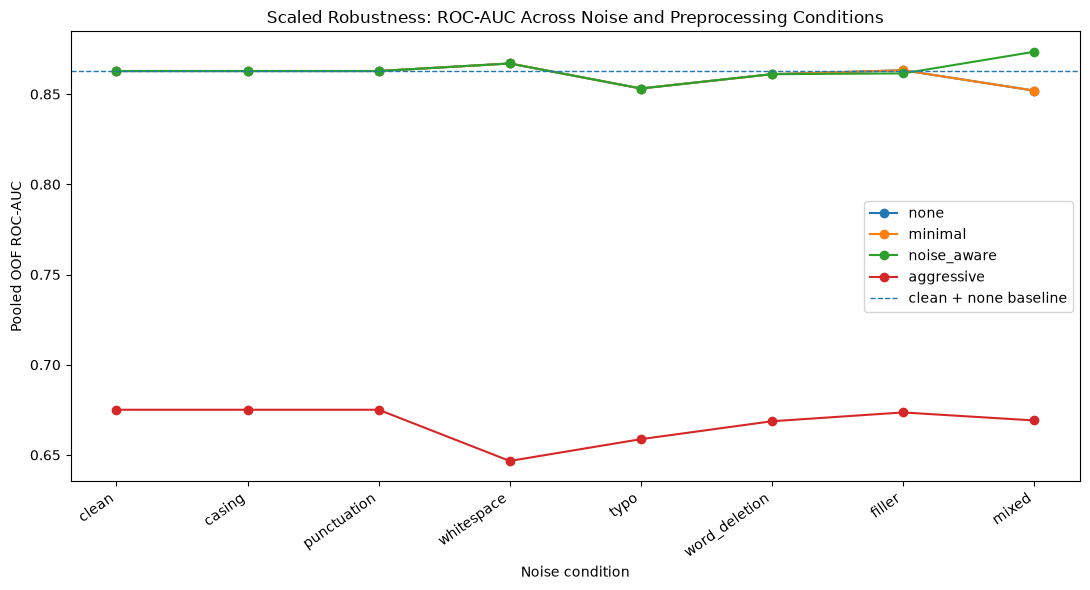

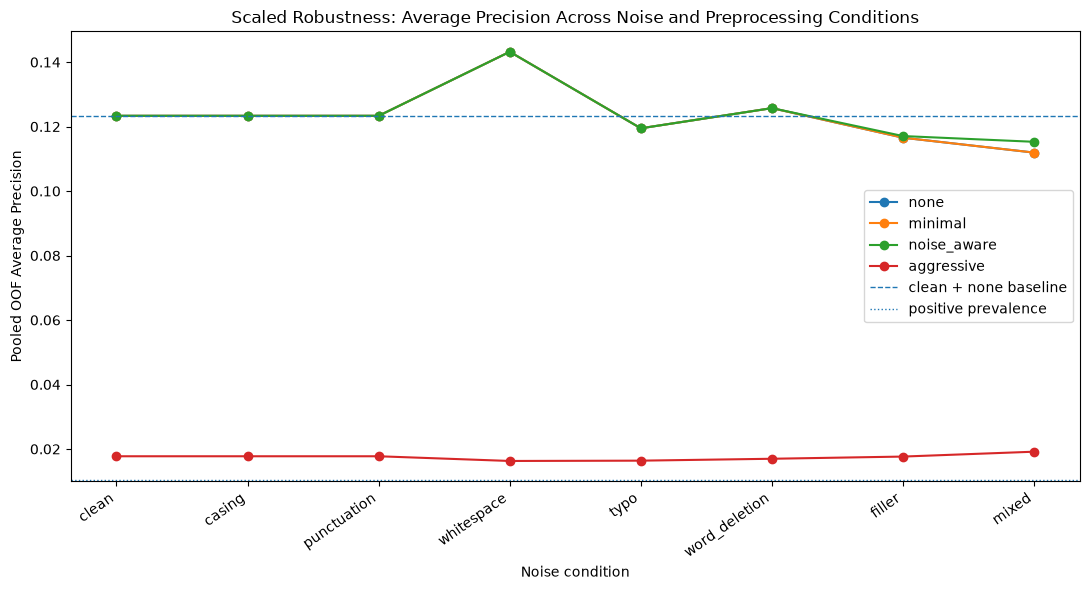

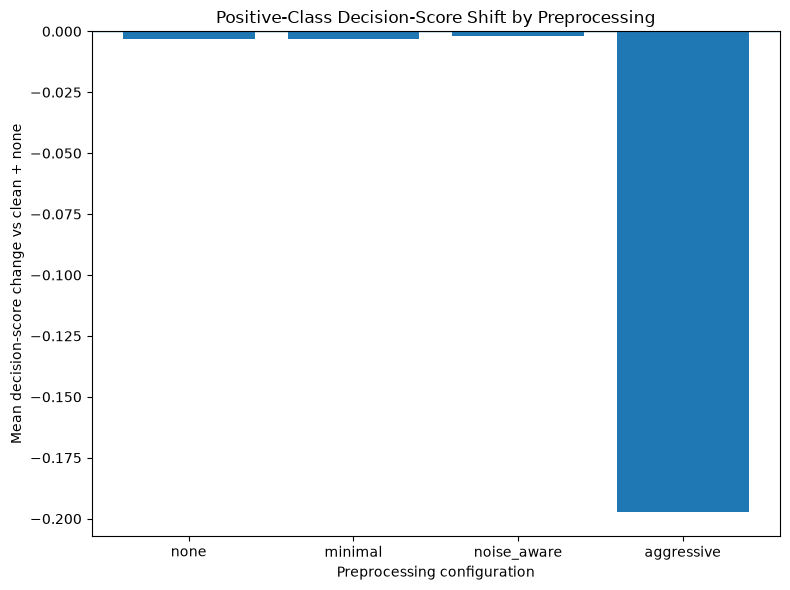

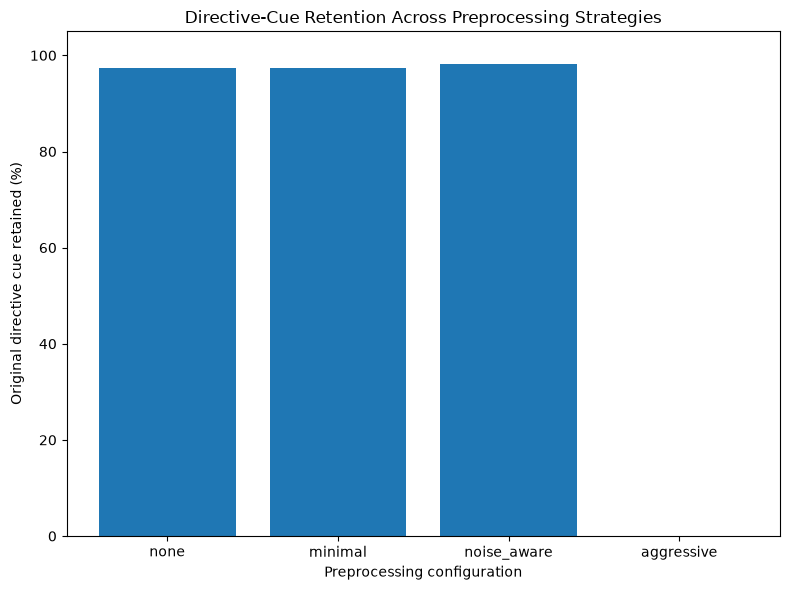

SAVED SCALED FIGURES
scaled_roc_auc_robustness.png -> /workspaces/irp-disempowerment-nlp/results/figures/scaled_roc_auc_robustness.png
scaled_average_precision_robustness.png -> /workspaces/irp-disempowerment-nlp/results/figures/scaled_average_precision_robustness.png
scaled_positive_score_shift.png -> /workspaces/irp-disempowerment-nlp/results/figures/scaled_positive_score_shift.png
scaled_directive_cue_retention.png -> /workspaces/irp-disempowerment-nlp/results/figures/scaled_directive_cue_retention.png

All four scaled figures saved successfully.


In [21]:
# ------------------------------------------------------------
# Final scaled-experiment figures
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np


RESULTS_FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

RESULTS_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Common ordering
# ------------------------------------------------------------

noise_order = list(NOISE_CONDITIONS)
preprocess_order = list(PREPROCESS_CONFIGS)

x = np.arange(
    len(noise_order)
)


# ============================================================
# FIGURE 1 — ROC-AUC robustness
# ============================================================

plt.figure(
    figsize=(11, 6)
)

for preprocess_config in preprocess_order:

    plot_df = (
        scaled_robustness_summary_df[
            scaled_robustness_summary_df[
                "preprocess_config"
            ] == preprocess_config
        ]
        .copy()
    )

    plot_df["noise_condition"] = pd.Categorical(
        plot_df["noise_condition"],
        categories=noise_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(
        "noise_condition"
    )

    plt.plot(
        x,
        plot_df["pooled_roc_auc"],
        marker="o",
        label=preprocess_config,
    )


plt.axhline(
    y=BASELINE_ROC_AUC,
    linestyle="--",
    linewidth=1,
    label="clean + none baseline",
)

plt.xticks(
    x,
    noise_order,
    rotation=35,
    ha="right",
)

plt.xlabel(
    "Noise condition"
)

plt.ylabel(
    "Pooled OOF ROC-AUC"
)

plt.title(
    "Scaled Robustness: ROC-AUC Across Noise and Preprocessing Conditions"
)

plt.legend()

plt.tight_layout()


scaled_roc_figure_path = (
    RESULTS_FIGURE_DIR
    / "scaled_roc_auc_robustness.png"
)

plt.savefig(
    scaled_roc_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# FIGURE 2 — Average Precision robustness
# ============================================================

plt.figure(
    figsize=(11, 6)
)

for preprocess_config in preprocess_order:

    plot_df = (
        scaled_robustness_summary_df[
            scaled_robustness_summary_df[
                "preprocess_config"
            ] == preprocess_config
        ]
        .copy()
    )

    plot_df["noise_condition"] = pd.Categorical(
        plot_df["noise_condition"],
        categories=noise_order,
        ordered=True,
    )

    plot_df = plot_df.sort_values(
        "noise_condition"
    )

    plt.plot(
        x,
        plot_df[
            "pooled_average_precision"
        ],
        marker="o",
        label=preprocess_config,
    )


plt.axhline(
    y=BASELINE_AP,
    linestyle="--",
    linewidth=1,
    label="clean + none baseline",
)

plt.axhline(
    y=17 / 1633,
    linestyle=":",
    linewidth=1,
    label="positive prevalence",
)

plt.xticks(
    x,
    noise_order,
    rotation=35,
    ha="right",
)

plt.xlabel(
    "Noise condition"
)

plt.ylabel(
    "Pooled OOF Average Precision"
)

plt.title(
    "Scaled Robustness: Average Precision Across Noise and Preprocessing Conditions"
)

plt.legend()

plt.tight_layout()


scaled_ap_figure_path = (
    RESULTS_FIGURE_DIR
    / "scaled_average_precision_robustness.png"
)

plt.savefig(
    scaled_ap_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# FIGURE 3 — Positive decision-score shift
# ============================================================

score_plot_df = (
    positive_preprocess_shift_df
    .copy()
)

score_plot_df[
    "preprocess_config"
] = pd.Categorical(
    score_plot_df[
        "preprocess_config"
    ],
    categories=preprocess_order,
    ordered=True,
)

score_plot_df = (
    score_plot_df
    .sort_values(
        "preprocess_config"
    )
)


plt.figure(
    figsize=(8, 6)
)

plt.bar(
    score_plot_df[
        "preprocess_config"
    ].astype(str),
    score_plot_df[
        "mean_delta"
    ],
)

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xlabel(
    "Preprocessing configuration"
)

plt.ylabel(
    "Mean decision-score change vs clean + none"
)

plt.title(
    "Positive-Class Decision-Score Shift by Preprocessing"
)

plt.tight_layout()


scaled_score_shift_figure_path = (
    RESULTS_FIGURE_DIR
    / "scaled_positive_score_shift.png"
)

plt.savefig(
    scaled_score_shift_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# FIGURE 4 — Directive-cue retention
# ============================================================

cue_plot_df = (
    cue_retention_summary_df
    .copy()
)

cue_plot_df[
    "preprocess_config"
] = pd.Categorical(
    cue_plot_df[
        "preprocess_config"
    ],
    categories=preprocess_order,
    ordered=True,
)

cue_plot_df = (
    cue_plot_df
    .sort_values(
        "preprocess_config"
    )
)


plt.figure(
    figsize=(8, 6)
)

plt.bar(
    cue_plot_df[
        "preprocess_config"
    ].astype(str),
    cue_plot_df[
        "any_cue_retention_pct"
    ],
)

plt.ylim(
    0,
    105,
)

plt.xlabel(
    "Preprocessing configuration"
)

plt.ylabel(
    "Original directive cue retained (%)"
)

plt.title(
    "Directive-Cue Retention Across Preprocessing Strategies"
)

plt.tight_layout()


scaled_cue_figure_path = (
    RESULTS_FIGURE_DIR
    / "scaled_directive_cue_retention.png"
)

plt.savefig(
    scaled_cue_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Verify saved figures
# ------------------------------------------------------------

figure_paths = [
    scaled_roc_figure_path,
    scaled_ap_figure_path,
    scaled_score_shift_figure_path,
    scaled_cue_figure_path,
]


print("=" * 80)
print("SAVED SCALED FIGURES")
print("=" * 80)

for path in figure_paths:

    assert path.exists()

    print(
        path.name,
        "->",
        path,
    )


print(
    "\nAll four scaled figures saved successfully."
)

## Scaled experiment results summary

The scaled experiment evaluated the frozen TF-IDF + LinearSVC baseline on
1,633 unique conversation sources using 3-fold stratified source-level
cross-validation. The audit-corrected binary target contained 17 positive
sources and 1,616 negative sources, corresponding to a positive prevalence
of 1.04%.

Models were fitted only on clean, unprocessed training responses and each
held-out source was evaluated across all 32 combinations of the frozen
`noise_v1` and `preprocess_v1` conditions.

### Clean baseline

For `clean + none`, the pooled out-of-fold results were:

- ROC-AUC: **0.8628**
- Average Precision: **0.1233**
- predicted positives at the default LinearSVC threshold: **0**
- true positives: **0**
- false negatives: **17**

Mean fold ROC-AUC was **0.8729** and mean fold Average Precision was
**0.1974**.

The absence of positive hard predictions means that accuracy, precision,
recall, and F1 at the default decision threshold are not informative measures
of useful classifier performance in this highly imbalanced setting. Ranking
metrics and decision-score behaviour are therefore used as the primary
robustness indicators.

### Effect of textual noise

When preprocessing was fixed at `none`, synthetic noise caused relatively
small changes in ranking performance.

ROC-AUC ranged from **0.8520 to 0.8670** across all noise conditions, compared
with **0.8628** for clean text. Average Precision ranged from **0.1119 to
0.1432**, compared with **0.1233** for clean text.

The worst noise-only condition was `mixed`, with ROC-AUC **0.8520** and
Average Precision **0.1119**, retaining approximately **90.8%** of clean
Average Precision.

The higher Average Precision observed for `whitespace` (**0.1432**) should
not be interpreted as evidence that adding noise improves classification.
With only 17 positive examples, small changes in ranking can produce
noticeable changes in Average Precision.

### Effect of preprocessing

The `none`, `minimal`, and `noise_aware` configurations produced very similar
performance:

- mean ROC-AUC: approximately **0.861–0.863**
- mean Average Precision: approximately **0.123–0.124**

In contrast, aggressive preprocessing substantially reduced ranking
performance:

- mean ROC-AUC: **0.6677**
- mean Average Precision: **0.0175**
- absolute ROC-AUC reduction relative to the mean non-aggressive result:
  **0.1937**
- absolute Average Precision reduction: **0.1061**

Aggressive preprocessing retained only approximately **14.1%** of the mean
non-aggressive Average Precision. Mean non-aggressive Average Precision was
approximately **7.08 times** the aggressive result.

The worst aggressive condition was `whitespace + aggressive`, with ROC-AUC
**0.6467** and Average Precision **0.0163**.

### Positive-class score sensitivity

Across the 17 audit-corrected positive sources, non-aggressive preprocessing
produced only small decision-score changes. The mean absolute shift was
approximately **0.0098**.

Aggressive preprocessing produced a mean absolute shift of **0.1973**, which
was approximately **20.17 times larger**.

Its mean signed shift was also **-0.1973**, and every observed aggressive
positive-source variant moved in the negative direction relative to its
clean/unprocessed baseline. The aggressive score changes ranged from
**-0.5057 to -0.0398**.

The most affected positive source was source `665360`, whose clean baseline
decision score was approximately **-0.4562** and whose mean aggressive score
fell to approximately **-0.9573**.

### Linguistic-cue preservation

Sixteen of the 17 corrected positive examples were classified as
`directive_advice`. Fourteen of those contained at least one of the exact
diagnostic modal constructions examined in the cue-preservation analysis,
including forms such as `you should`, `you must`, `you need to`, and
`you have to`.

Across those cue-bearing examples:

- `none` retained at least one original cue in **97.3%** of variants;
- `minimal` retained at least one original cue in **97.3%**;
- `noise_aware` retained at least one original cue in **98.2%**;
- `aggressive` retained an original cue in **0%**.

The small losses under the non-aggressive configurations occurred only under
`mixed` synthetic noise. For clean, casing, punctuation, whitespace, typo,
and filler conditions, the non-aggressive configurations retained 100% of
the tracked cues.

Aggressive preprocessing therefore systematically removed the modal and
subject constructions associated with directive language while retaining
substantial amounts of topical vocabulary. For example, source `665360`
contained repeated constructions such as `you should ...`; aggressive
preprocessing reduced the response to content words such as `talk`,
`commanding officer`, `paperwork`, and `leave`, with approximately **43.2%**
word retention.

### Overall scaled-experiment finding

The scaled results indicate that the tested classifier is comparatively
robust to the synthetic textual noise introduced by `noise_v1`, but is highly
sensitive to aggressive text cleaning.

The degradation under aggressive preprocessing is visible at three related
levels:

1. substantially lower ROC-AUC and Average Precision;
2. systematic downward movement of positive-class decision scores; and
3. complete removal of the tracked directive modal constructions.

This supports the data-centric interpretation that preprocessing choices can
remove linguistically meaningful information even when much of the semantic
topic content remains.

These findings remain subject to the limitations of the audit-corrected
weak-label target. Only 17 positive sources were identified, the weak-positive
audit showed substantial false-positive behaviour, and only a deterministic
sample of weak-negative examples was manually checked for false negatives.
The results should therefore be interpreted as evidence about robustness to
preprocessing within this experimental corpus, rather than as population-level
estimates of disempowerment detection performance.

In [22]:
# ------------------------------------------------------------
# Notebook 06 final integrity check
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Core local data artefacts
# ------------------------------------------------------------

core_data_files = {
    "audit_corrected_target": (
        SCALED_DATA_DIR
        / "lmsys_full_audit_corrected_target_1633.csv"
    ),
    "scaled_matrix": (
        SCALED_DATA_DIR
        / "lmsys_scaled_noise_preprocess_v1_matrix_52256.csv"
    ),
    "positive_audit": (
        SCALED_DATA_DIR
        / "lmsys_full_weak_v5_positive_audit_56.csv"
    ),
    "negative_audit": (
        SCALED_DATA_DIR
        / "lmsys_full_weak_v5_negative_audit_100.csv"
    ),
}


# ------------------------------------------------------------
# Result tables expected in Git
# ------------------------------------------------------------

result_table_files = [
    "scaled_fold_condition_metrics.csv",
    "scaled_oof_predictions_52256.csv",
    "scaled_robustness_summary_32_conditions.csv",
    "scaled_degradation_vs_clean.csv",
    "scaled_preprocess_effect_summary.csv",
    "scaled_noise_only_sensitivity.csv",
    "scaled_positive_score_shifts.csv",
    "scaled_positive_source_stability.csv",
    "scaled_directive_cue_retention.csv",
    "scaled_directive_cue_retention_summary.csv",
    "scaled_nonaggressive_cue_retention_by_noise.csv",
    "scaled_nonaggressive_cue_loss_cases.csv",
]


# ------------------------------------------------------------
# Result figures expected in Git
# ------------------------------------------------------------

result_figure_files = [
    "scaled_roc_auc_robustness.png",
    "scaled_average_precision_robustness.png",
    "scaled_positive_score_shift.png",
    "scaled_directive_cue_retention.png",
]


print("=" * 80)
print("CORE DATA ARTEFACTS")
print("=" * 80)

for name, path in core_data_files.items():

    assert path.exists(), f"Missing: {path}"

    print(
        f"{name}: OK -> {path.name}"
    )


print("\n" + "=" * 80)
print("RESULT TABLES")
print("=" * 80)

for filename in result_table_files:

    path = RESULTS_TABLE_DIR / filename

    assert path.exists(), f"Missing: {path}"

    print(
        f"OK -> {filename}"
    )


print("\n" + "=" * 80)
print("RESULT FIGURES")
print("=" * 80)

for filename in result_figure_files:

    path = RESULTS_FIGURE_DIR / filename

    assert path.exists(), f"Missing: {path}"

    print(
        f"OK -> {filename}"
    )


# ------------------------------------------------------------
# Reload key outputs from disk
# ------------------------------------------------------------

final_target_check = pd.read_csv(
    core_data_files[
        "audit_corrected_target"
    ]
)

matrix_check = pd.read_csv(
    core_data_files[
        "scaled_matrix"
    ]
)

robustness_check = pd.read_csv(
    RESULTS_TABLE_DIR
    / "scaled_robustness_summary_32_conditions.csv"
)


# ------------------------------------------------------------
# Headline integrity assertions
# ------------------------------------------------------------

assert len(final_target_check) == 1633
assert final_target_check["source_index"].nunique() == 1633
assert int(final_target_check["target_label"].sum()) == 17

assert len(matrix_check) == 52256
assert matrix_check["source_index"].nunique() == 1633

assert len(robustness_check) == 32


clean_check = (
    robustness_check[
        (
            robustness_check[
                "noise_condition"
            ] == "clean"
        )
        &
        (
            robustness_check[
                "preprocess_config"
            ] == "none"
        )
    ]
    .iloc[0]
)


assert round(
    float(
        clean_check[
            "pooled_roc_auc"
        ]
    ),
    4,
) == 0.8628

assert round(
    float(
        clean_check[
            "pooled_average_precision"
        ]
    ),
    4,
) == 0.1233


print("\n" + "=" * 80)
print("HEADLINE RESULTS")
print("=" * 80)

print(
    "Final target:",
    len(final_target_check),
    "sources |",
    int(
        final_target_check[
            "target_label"
        ].sum()
    ),
    "positives",
)

print(
    "Scaled matrix:",
    len(matrix_check),
    "rows",
)

print(
    "Experimental conditions:",
    len(robustness_check),
)

print(
    "Clean + none ROC-AUC:",
    round(
        float(
            clean_check[
                "pooled_roc_auc"
            ]
        ),
        4,
    ),
)

print(
    "Clean + none AP:",
    round(
        float(
            clean_check[
                "pooled_average_precision"
            ]
        ),
        4,
    ),
)

print(
    "\nNOTEBOOK 06 FINAL INTEGRITY CHECK PASSED."
)

CORE DATA ARTEFACTS
audit_corrected_target: OK -> lmsys_full_audit_corrected_target_1633.csv
scaled_matrix: OK -> lmsys_scaled_noise_preprocess_v1_matrix_52256.csv
positive_audit: OK -> lmsys_full_weak_v5_positive_audit_56.csv
negative_audit: OK -> lmsys_full_weak_v5_negative_audit_100.csv

RESULT TABLES
OK -> scaled_fold_condition_metrics.csv
OK -> scaled_oof_predictions_52256.csv
OK -> scaled_robustness_summary_32_conditions.csv
OK -> scaled_degradation_vs_clean.csv
OK -> scaled_preprocess_effect_summary.csv
OK -> scaled_noise_only_sensitivity.csv
OK -> scaled_positive_score_shifts.csv
OK -> scaled_positive_source_stability.csv
OK -> scaled_directive_cue_retention.csv
OK -> scaled_directive_cue_retention_summary.csv
OK -> scaled_nonaggressive_cue_retention_by_noise.csv
OK -> scaled_nonaggressive_cue_loss_cases.csv

RESULT FIGURES
OK -> scaled_roc_auc_robustness.png
OK -> scaled_average_precision_robustness.png
OK -> scaled_positive_score_shift.png
OK -> scaled_directive_cue_retention